In [1]:
# =============================================================================
# 02b_carbonate_system.ipynb — SISTEMA DE CARBONATOS
# Banco Burdwood — BBI (plateau) y BBII (slope)
# =============================================================================
# Variables analizadas:
#   - omega_ar : estado de saturación de aragonita
#   - omega_ca : estado de saturación de calcita
#   - Revelle factor : capacidad buffer (calculado a partir de talk y tco2)
#
# Umbrales biológicos relevantes:
#   - Ω_ar < 1.5 → estrés subletal pterópodos (Limacina spp.)
#   - Ω_ar < 1.0 → disolución activa de aragonita
#   - Ω_ca < 1.0 → disolución activa de calcita (cocolitofóridos)
#
# Organismos de interés:
#   - Pterópodos    : Limacina helicina, L. retroversa (aragonita)
#   - Cocolitofóridos: Emiliania huxleyi (calcita)
#   - Copépodos     : Calanus simillimus (efectos indirectos)
# =============================================================================

#### Librerías y paths

In [1]:
# =============================================================================
# CELDA 1 — Librerías y paths
# =============================================================================
 
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import STL
from pymannkendall import original_test as mk_test
from scipy.stats import theilslopes
 
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
 
# Umbrales biológicos
THRESH_AR_STRESS = 1.5   # estrés subletal pterópodos
THRESH_AR_DISS   = 1.0   # disolución aragonita
THRESH_CA_DISS   = 1.0   # disolución calcita
 
print("Setup listo ✅")
print(f"Umbrales: Ω_ar stress={THRESH_AR_STRESS}, Ω_ar diss={THRESH_AR_DISS}, Ω_ca diss={THRESH_CA_DISS}")
 

Setup listo ✅
Umbrales: Ω_ar stress=1.5, Ω_ar diss=1.0, Ω_ca diss=1.0


#### Carga de datos

In [2]:
# =============================================================
# PALETA GLOBAL — daltónico-friendly (Wong 2011)
# =============================================================

# Zonas
COLOR_BBI  = "#009E73"  # verde esmeralda
COLOR_BBII = "#E69F00"  # naranja dorado

# Umbrales biológicos — por severidad
COLOR_WARN = "#D55E00"  # naranja rojizo — alerta temprana
COLOR_CRIT = "#CC79A7"  # rosa/magenta  — umbral crítico
COLOR_PCO2 = "#0072B2"  # azul          — umbral pCO₂ E. huxleyi

In [3]:
# =============================================================================
# CELDA 2 — Carga de datos
# Usamos ph_BBI.nc y ph_BBII.nc (no los _ready) porque tienen
# todas las variables del sistema de carbonatos
# =============================================================================
 
ds_BBI  = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBI_ready.nc"))
ds_BBII = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBII_ready.nc"))
 
# Verificar variables disponibles
print("Variables disponibles:")
print(list(ds_BBI.data_vars))
 
# Ordenar por tiempo (mismo preprocesamiento mínimo que en 01c)
ds_BBI  = ds_BBI.sortby("time").drop_duplicates(dim="time")
ds_BBII = ds_BBII.sortby("time").drop_duplicates(dim="time")
 
print(f"\nPeríodo: {str(ds_BBI.time.values[0])[:10]} → {str(ds_BBI.time.values[-1])[:10]}")
print(f"N meses: {ds_BBI.sizes['time']}")

Variables disponibles:
['fgco2', 'fgco2_uncertainty', 'omega_ar', 'omega_ar_uncertainty', 'omega_ca', 'omega_ca_uncertainty', 'ph', 'ph_uncertainty', 'spco2', 'spco2_uncertainty', 'talk', 'talk_uncertainty', 'tco2', 'tco2_uncertainty']

Período: 1985-01-01 → 2024-12-01
N meses: 480


#### Exploración inicial: distribución de datos

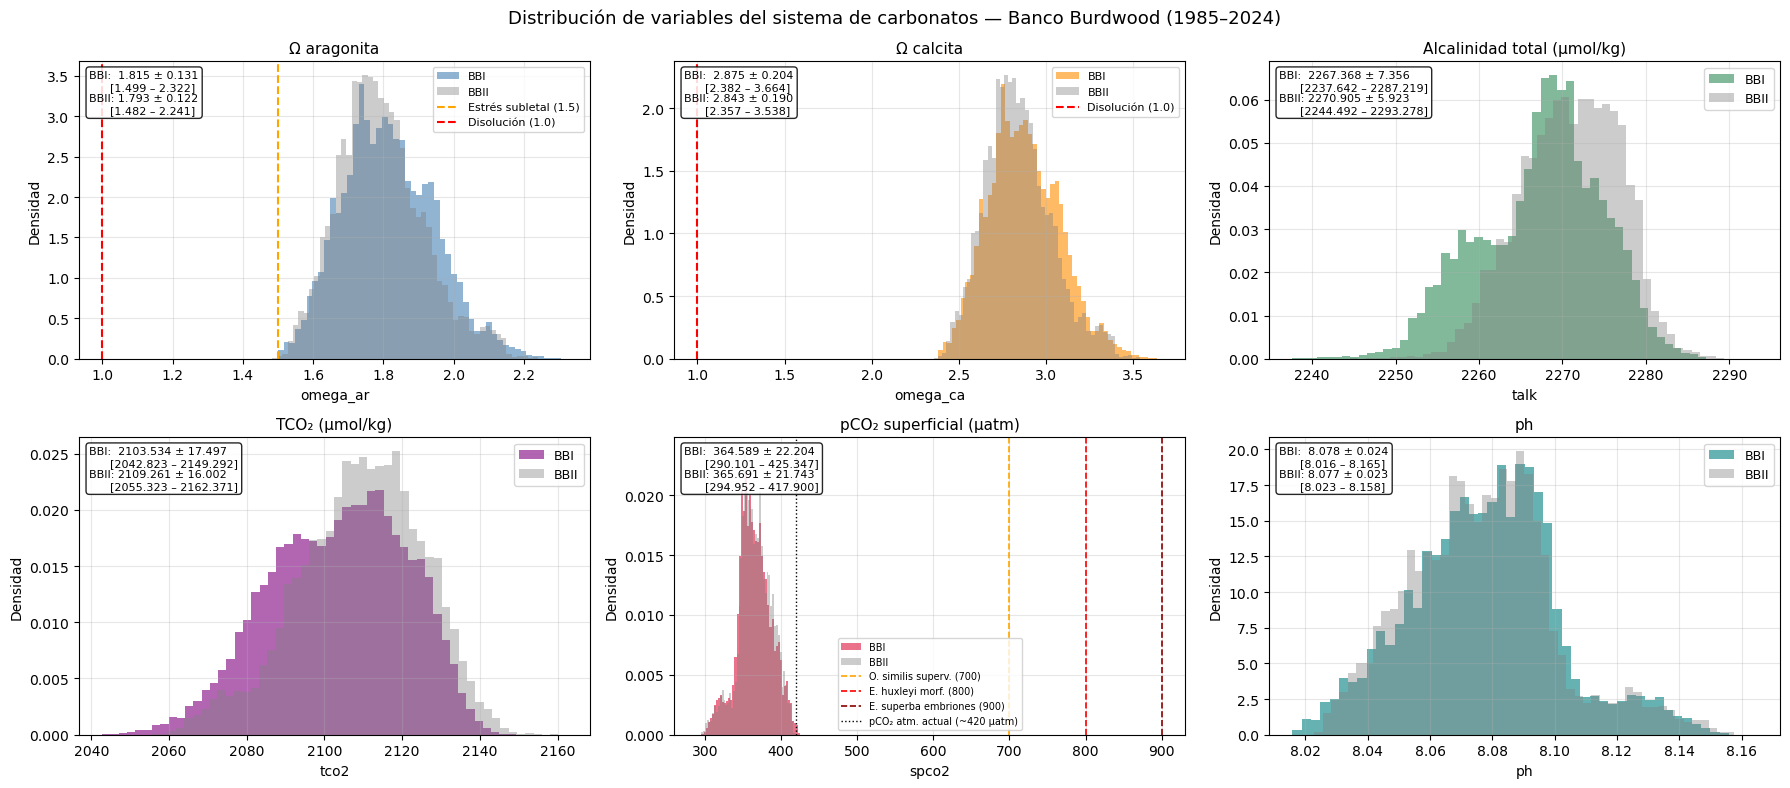

✅ Figura guardada: carbonate_distributions.png


In [4]:
# =============================================================================
# CELDA 3 — Exploración inicial: distribución de datos
# =============================================================================
# Antes de cualquier análisis, miramos la distribución real de los datos
# para entender el rango de valores en el BB y decidir si hace falta filtro
 
def get_values(ds, varname):
    """Extrae todos los valores no-NaN de una variable."""
    vals = ds[varname].values.ravel()
    return vals[~np.isnan(vals)]
 
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

variables = ["omega_ar", "omega_ca", "talk", "tco2", "spco2", "ph"]
titulos   = ["Ω aragonita", "Ω calcita", "Alcalinidad total (µmol/kg)", "TCO₂ (µmol/kg)", "pCO₂ superficial (µatm)", "ph"]
colores   = ["steelblue", "darkorange", "seagreen", "purple", "crimson", "teal"]

for ax, var, titulo, color in zip(axes.ravel(), variables, titulos, colores):
    vals_BBI  = get_values(ds_BBI,  var)
    vals_BBII = get_values(ds_BBII, var)

    ax.hist(vals_BBI,  bins=50, alpha=0.6, color=color, label="BBI",  density=True)
    ax.hist(vals_BBII, bins=50, alpha=0.4, color="gray", label="BBII", density=True)

    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel(var)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    stats_txt = (f"BBI:  {vals_BBI.mean():.3f} ± {vals_BBI.std():.3f}\n"
                 f"      [{vals_BBI.min():.3f} – {vals_BBI.max():.3f}]\n"
                 f"BBII: {vals_BBII.mean():.3f} ± {vals_BBII.std():.3f}\n"
                 f"      [{vals_BBII.min():.3f} – {vals_BBII.max():.3f}]")
    ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

    # Umbrales biológicos
    if var == "omega_ar":
        ax.axvline(THRESH_AR_STRESS, color="orange", lw=1.5,
                   linestyle="--", label=f"Estrés subletal ({THRESH_AR_STRESS})")
        ax.axvline(THRESH_AR_DISS,   color="red",    lw=1.5,
                   linestyle="--", label=f"Disolución ({THRESH_AR_DISS})")
        ax.legend(fontsize=8)
    elif var == "omega_ca":
        ax.axvline(THRESH_CA_DISS, color="red", lw=1.5,
                   linestyle="--", label=f"Disolución ({THRESH_CA_DISS})")
        ax.legend(fontsize=8)
    elif var == "spco2":
        # Umbrales biológicos de pCO2 de la tabla de especies
        umbrales_pco2 = [
            (700,  "orange", "O. similis superv."),
            (800,  "red",    "E. huxleyi morf."),
            (900,  "darkred","E. superba embriones"),
        ]
        for val, col, lbl in umbrales_pco2:
            ax.axvline(val, color=col, lw=1.2, linestyle="--", label=f"{lbl} ({val})")
        # Línea de pCO2 atmosférico actual (~420 µatm)
        ax.axvline(420, color="black", lw=1.0, linestyle=":", label="pCO₂ atm. actual (~420 µatm)")
        ax.legend(fontsize=7)



plt.suptitle("Distribución de variables del sistema de carbonatos — Banco Burdwood (1985–2024)",
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "carbonate_distributions.png"), dpi=150)
plt.show()
print("✅ Figura guardada: carbonate_distributions.png")

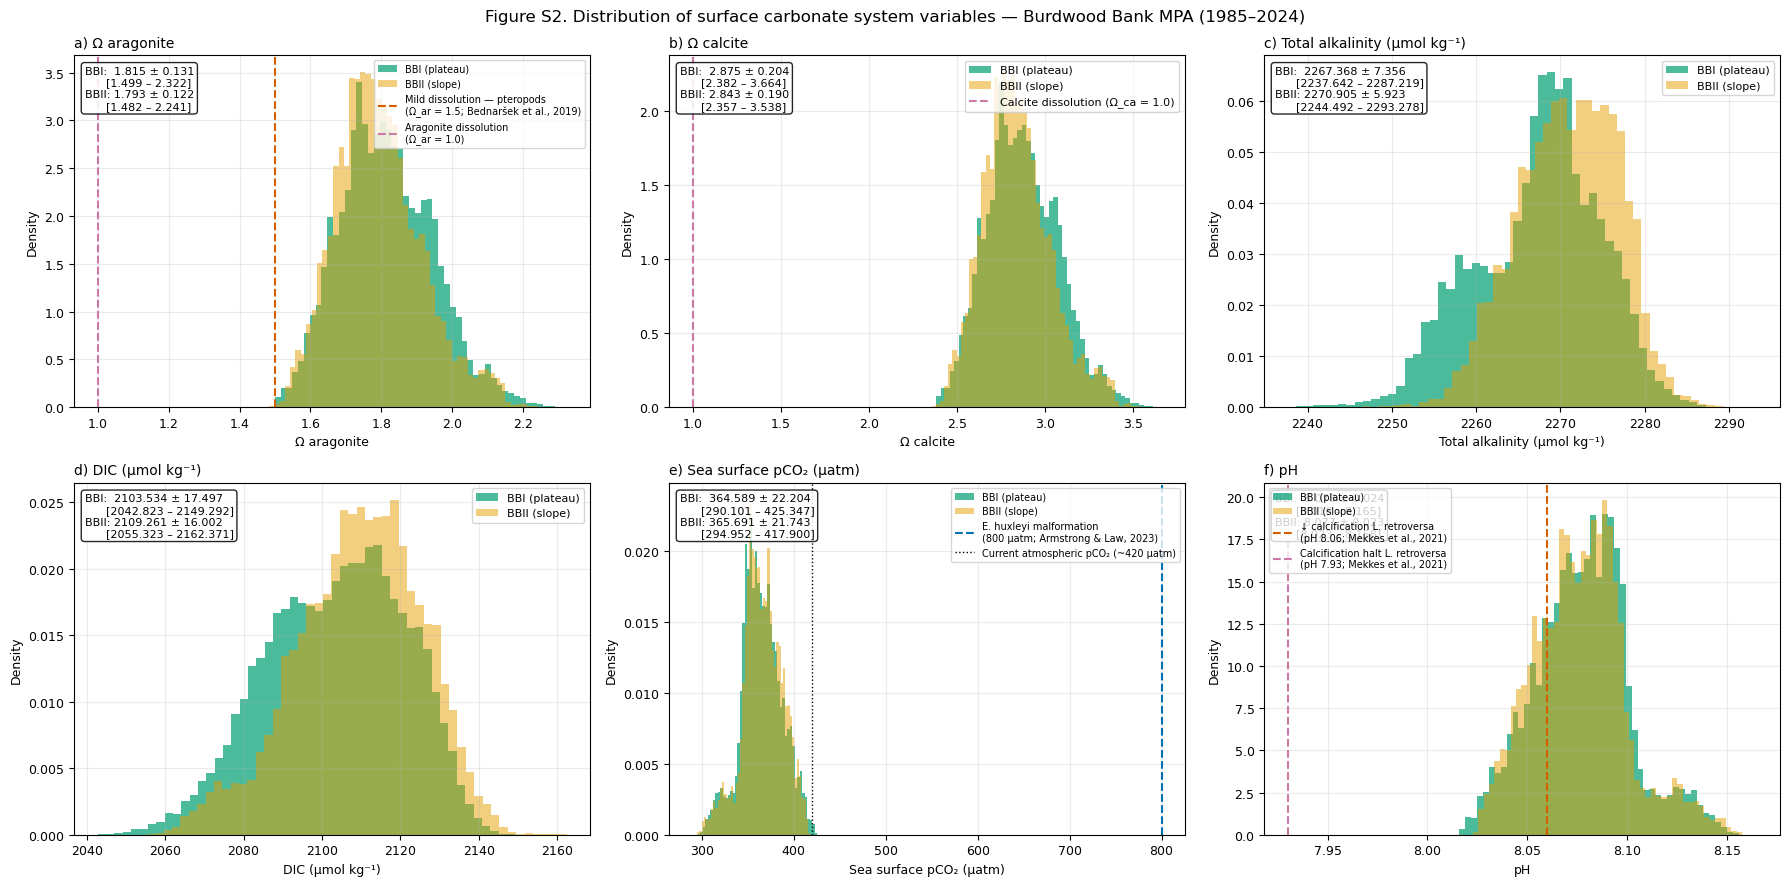

✅ FigS2_carbonate_distributions.png guardada


In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# FigS2 — Distribution of carbonate system variables — Supplementary Material
# =============================================================================

# Colores daltónico-friendly (Wong 2011)
COLOR_BBI  = "#009E73"
COLOR_BBII = "#E69F00"
COLOR_WARN = "#D55E00"
COLOR_CRIT = "#CC79A7"
COLOR_PCO2 = "#0072B2"

def get_values(ds, varname):
    vals = ds[varname].values.ravel()
    return vals[~np.isnan(vals)]

variables = ["omega_ar", "omega_ca", "talk",             "tco2",          "spco2",              "ph"]
titulos   = ["Ω aragonite", "Ω calcite", "Total alkalinity (µmol kg⁻¹)", "DIC (µmol kg⁻¹)", "Sea surface pCO₂ (µatm)", "pH"]
letras    = ["a)", "b)", "c)", "d)", "e)", "f)"]

plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, var, titulo, letra in zip(axes.ravel(), variables, titulos, letras):

    vals_BBI  = get_values(ds_BBI,  var)
    vals_BBII = get_values(ds_BBII, var)

    ax.hist(vals_BBI,  bins=50, alpha=0.7, color=COLOR_BBI,
            label="BBI (plateau)", density=True)
    ax.hist(vals_BBII, bins=50, alpha=0.5, color=COLOR_BBII,
            label="BBII (slope)", density=True)

    ax.set_title(f"{letra} {titulo}", fontsize=10, loc="left")
    ax.set_xlabel(titulo, fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

    # Estadísticas en el recuadro
    stats_txt = (
        f"BBI:  {vals_BBI.mean():.3f} ± {vals_BBI.std():.3f}\n"
        f"      [{vals_BBI.min():.3f} – {vals_BBI.max():.3f}]\n"
        f"BBII: {vals_BBII.mean():.3f} ± {vals_BBII.std():.3f}\n"
        f"      [{vals_BBII.min():.3f} – {vals_BBII.max():.3f}]"
    )
    ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes,
            fontsize=8, va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

    # Umbrales biológicos
    if var == "omega_ar":
        ax.axvline(1.5, color=COLOR_WARN, lw=1.5, linestyle="--",
                   label="Mild dissolution — pteropods\n(Ω_ar = 1.5; Bednaršek et al., 2019)")
        ax.axvline(1.0, color=COLOR_CRIT, lw=1.5, linestyle="--",
                   label="Aragonite dissolution\n(Ω_ar = 1.0)")
        ax.legend(fontsize=7, loc="upper right")

    elif var == "omega_ca":
        ax.axvline(1.0, color=COLOR_CRIT, lw=1.5, linestyle="--",
                   label="Calcite dissolution (Ω_ca = 1.0)")
        ax.legend(fontsize=8, loc="upper right")

    elif var == "spco2":
        ax.axvline(800, color=COLOR_PCO2, lw=1.5, linestyle="--",
                   label="E. huxleyi malformation\n(800 µatm; Armstrong & Law, 2023)")
        ax.axvline(420, color="black", lw=1.0, linestyle=":",
                   label="Current atmospheric pCO₂ (~420 µatm)")
        ax.legend(fontsize=7, loc="upper right")

    elif var == "ph":
        ax.axvline(8.06, color=COLOR_WARN, lw=1.5, linestyle="--",
                   label="↓ calcification L. retroversa\n(pH 8.06; Mekkes et al., 2021)")
        ax.axvline(7.93, color=COLOR_CRIT, lw=1.5, linestyle="--",
                   label="Calcification halt L. retroversa\n(pH 7.93; Mekkes et al., 2021)")
        ax.legend(fontsize=7, loc="upper left")

plt.suptitle(
    "Figure S2. Distribution of surface carbonate system variables — "
    "Burdwood Bank MPA (1985–2024)",
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "FigS2_carbonate_distributions.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ FigS2_carbonate_distributions.png guardada")

#### Promedio espacial ponderado por área

In [5]:
# =============================================================================
# CELDA 4 — Promedio espacial ponderado por área
# (misma función que en 02_ph_analysis)
# =============================================================================
 
def spatial_mean_weighted(ds, varname):
    """
    Promedio espacial ponderado por coseno de latitud.
    Ver explicación detallada en 02_ph_analysis, Celda 3.
    """
    weights = np.cos(np.deg2rad(ds["latitude"]))
    da = ds[varname].weighted(weights).mean(
        dim=["latitude", "longitude"], skipna=True
    )
    return da
 
 
def to_dataframe(ds, variables):
    """
    Convierte múltiples variables a un DataFrame con columnas de tiempo.
    """
    dfs = []
    for var in variables:
        da = spatial_mean_weighted(ds, var)
        df = da.to_dataframe(name=var).reset_index()
        dfs.append(df.set_index("time")[var])
 
    df_out = pd.concat(dfs, axis=1).reset_index()
    df_out["time"]  = pd.to_datetime(df_out["time"])
    df_out["year"]  = df_out["time"].dt.year
    df_out["month"] = df_out["time"].dt.month
    return df_out
 
 
VARS = ["omega_ar", "omega_ca", "talk", "tco2", "spco2", "ph"]
 
df_BBI  = to_dataframe(ds_BBI,  VARS)
df_BBII = to_dataframe(ds_BBII, VARS)
 
print("=== BBI ===")
print(df_BBI[VARS].describe().round(4))
print("\n=== BBII ===")
print(df_BBII[VARS].describe().round(4))

=== BBI ===
       omega_ar  omega_ca       talk       tco2     spco2        ph
count  480.0000  480.0000   480.0000   480.0000  480.0000  480.0000
mean     1.8146    2.8753  2267.3528  2103.5183  364.5870    8.0778
std      0.1295    0.2018     5.5205    16.6649   21.9848    0.0236
min      1.5218    2.4168  2250.0356  2054.7727  304.3087    8.0200
25%      1.7239    2.7358  2262.4368  2091.2421  350.4932    8.0615
50%      1.8090    2.8663  2266.6125  2104.2362  362.9058    8.0785
75%      1.9043    3.0148  2271.9777  2116.5111  378.9698    8.0927
max      2.2389    3.5365  2279.4729  2138.2134  420.7195    8.1472

=== BBII ===
       omega_ar  omega_ca       talk       tco2     spco2        ph
count  480.0000  480.0000   480.0000   480.0000  480.0000  480.0000
mean     1.7933    2.8428  2270.8896  2109.2366  365.6862    8.0768
std      0.1190    0.1859     4.8915    15.3531   21.6087    0.0233
min      1.5437    2.4515  2256.7297  2062.9517  299.5119    8.0271
25%      1.7083    2.7

Esto es distinto a lo que mostró el histograma antes — el histograma mostraba valores llegando a ~1.48 pero la tabla dice 1.52. La diferencia es que el histograma usaba todos los píxeles individuales y la tabla usa el promedio espacial ponderado. El promedio suaviza los extremos — los píxeles individuales más extremos quedan enmascarados en el promedio. El promedio espacial del BB nunca bajó del umbral de estrés subletal de pterópodos (Ω_ar = 1.5), pero píxeles individuales sí lo hicieron.

#### Series temporales de omega_ar y omega_ca con umbrales biológicos

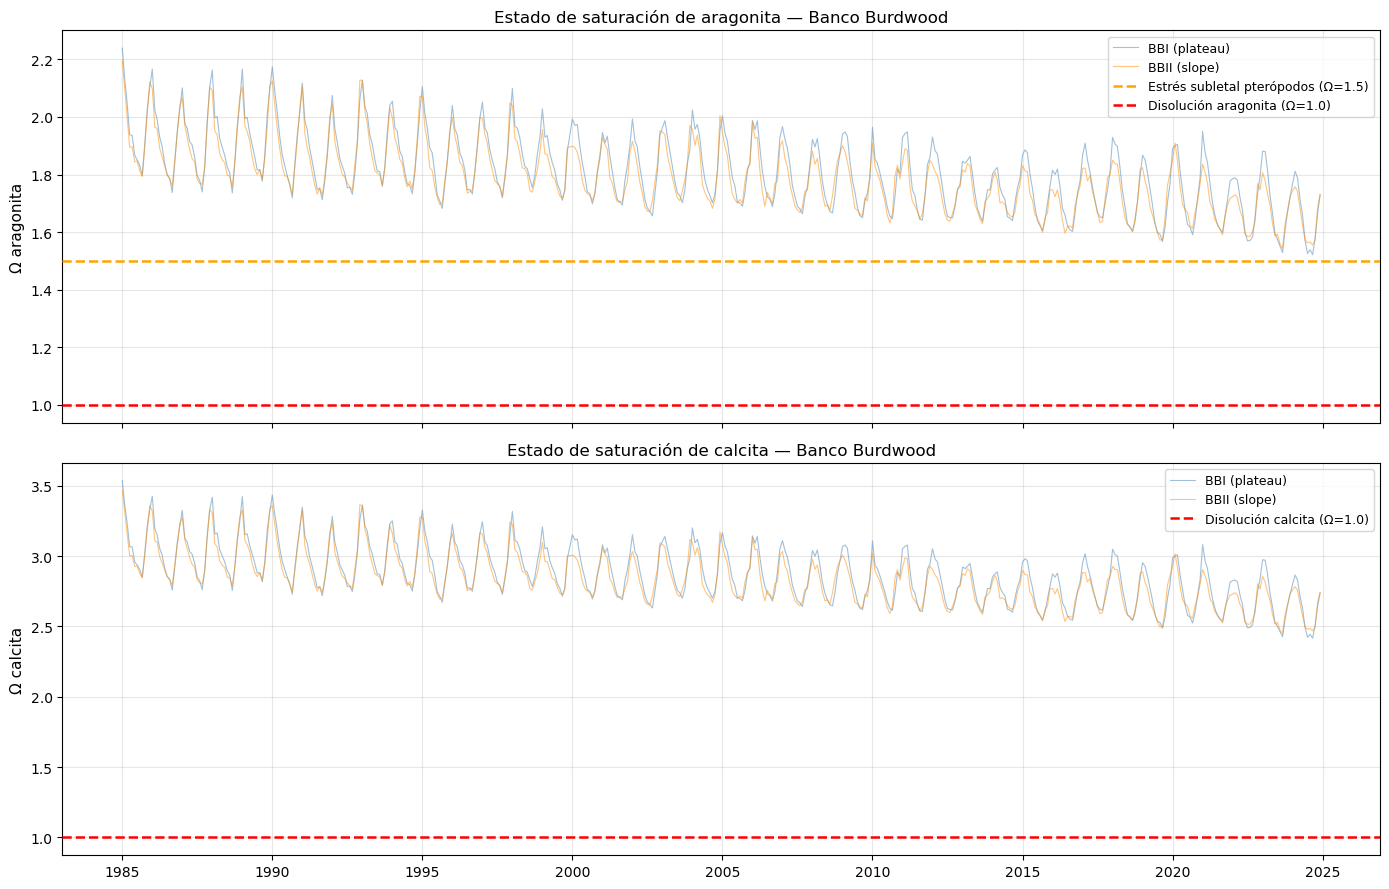

✅ Figura guardada: omega_timeseries.png


In [6]:
# =============================================================================
# CELDA 5 — Series temporales de omega_ar y omega_ca con umbrales biológicos
# =============================================================================
 
def plot_omega_timeseries(df_BBI, df_BBII):
    """
    Serie temporal mensual de Ω_ar y Ω_ca para BBI y BBII.
    Incluye líneas de umbrales biológicos críticos.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
 
    for ax, var, ylabel, thresholds, title in [
        (axes[0], "omega_ar", "Ω aragonita",
         [(THRESH_AR_STRESS, "orange", f"Estrés subletal pterópodos (Ω={THRESH_AR_STRESS})"),
          (THRESH_AR_DISS,   "red",    f"Disolución aragonita (Ω={THRESH_AR_DISS})")],
         "Estado de saturación de aragonita — Banco Burdwood"),
        (axes[1], "omega_ca", "Ω calcita",
         [(THRESH_CA_DISS, "red", f"Disolución calcita (Ω={THRESH_CA_DISS})")],
         "Estado de saturación de calcita — Banco Burdwood"),
    ]:
        # Series mensuales
        ax.plot(df_BBI["time"],  df_BBI[var],
                color="steelblue", alpha=0.5, lw=0.8, label="BBI (plateau)")
        ax.plot(df_BBII["time"], df_BBII[var],
                color="darkorange", alpha=0.5, lw=0.8, label="BBII (slope)")
 
        # Umbrales biológicos
        for thresh_val, thresh_color, thresh_label in thresholds:
            ax.axhline(thresh_val, color=thresh_color, lw=1.8,
                       linestyle="--", label=thresh_label, zorder=3)
 
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.legend(fontsize=9, loc="upper right")
        ax.grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "omega_timeseries.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Figura guardada: omega_timeseries.png")
 
 
plot_omega_timeseries(df_BBI, df_BBII)

#### Tendencia: Sen's slope + Mann-Kendall para omega_ar y omega_ca

In [7]:
# =============================================================================
# CELDA 6 — Tendencia: Sen's slope + Mann-Kendall para omega_ar y omega_ca
# =============================================================================
 
def compute_trend_var(df, varname, region_name):
    """
    Sen's slope + Mann-Kendall sobre la serie mensual de una variable.
    (misma metodología que en 02_ph_analysis para pH)
    """
    # Descomposición STL para extraer tendencia
    series = df.set_index("time")[varname].asfreq("MS")
    stl    = STL(series, period=12, robust=True)
    result = stl.fit()
    trend  = result.trend.values
 
    x = np.arange(len(trend))
    slope, intercept, low_slope, high_slope = theilslopes(trend, x)
 
    # Convertir a unidades/año y /década
    slope_yr  = slope * 12
    slope_dec = slope * 120
    low_yr    = low_slope  * 12
    high_yr   = high_slope * 12
 
    mk_result = mk_test(trend)
 
    print(f"\n{'='*55}")
    print(f"  TENDENCIA {varname} — {region_name}")
    print(f"{'='*55}")
    print(f"  Sen's slope  : {slope_yr:.5f} /año")
    print(f"               : {slope_dec:.4f} /década")
    print(f"  IC 95%       : [{low_yr:.5f}, {high_yr:.5f}] /año")
    print(f"  Mann-Kendall : {mk_result.trend}")
    print(f"  p-valor      : {mk_result.p:.4e}")
    sig = ('*** p<0.001' if mk_result.p < 0.001 else
           '** p<0.01'   if mk_result.p < 0.01  else
           '* p<0.05'    if mk_result.p < 0.05  else
           'no significativa')
    print(f"  Significancia: {sig}")
 
    return {
        "region": region_name, "var": varname,
        "slope_yr": slope_yr, "slope_dec": slope_dec,
        "IC_low_yr": low_yr, "IC_high_yr": high_yr,
        "mk_trend": mk_result.trend, "mk_p": mk_result.p,
        "trend_series": trend, "stl_seasonal": result.seasonal.values,
    }
 
 
# Calcular tendencias para omega_ar y omega_ca
trends = {}
for var in ["omega_ar", "omega_ca", "spco2"]:
    for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
        key = f"{var}_{region}"
        trends[key] = compute_trend_var(df, var, region)


  TENDENCIA omega_ar — BBI
  Sen's slope  : -0.00668 /año
               : -0.0668 /década
  IC 95%       : [-0.00683, -0.00653] /año
  Mann-Kendall : decreasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001

  TENDENCIA omega_ar — BBII
  Sen's slope  : -0.00673 /año
               : -0.0673 /década
  IC 95%       : [-0.00686, -0.00661] /año
  Mann-Kendall : decreasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001

  TENDENCIA omega_ca — BBI
  Sen's slope  : -0.01056 /año
               : -0.1056 /década
  IC 95%       : [-0.01078, -0.01033] /año
  Mann-Kendall : decreasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001

  TENDENCIA omega_ca — BBII
  Sen's slope  : -0.01063 /año
               : -0.1063 /década
  IC 95%       : [-0.01083, -0.01045] /año
  Mann-Kendall : decreasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001

  TENDENCIA spco2 — BBI
  Sen's slope  : 1.62366 /año
               : 16.2366 /década
  IC 95%       : [1.60497, 1.6

Dos cosas muy notables:
1. Ω_ca cae más rápido que Ω_ar en términos absolutos
Esto es contraintuitivo a primera vista porque la calcita es más estable que la aragonita. Pero tiene sentido químico — la tasa de cambio absoluta depende del nivel inicial (Ω_ca parte de ~2.87 vs Ω_ar de ~1.81).
2. BBI y BBII son prácticamente idénticos
Igual que con el pH — forzante regional homogéneo dominando sobre diferencias locales.

#### Proyección simple — ¿cuándo se cruza el umbral?

In [8]:
# Podés correr esto en una celda nueva
omega_ar_mean_2024 = df_BBI[df_BBI["year"]==2024]["omega_ar"].mean()
slope_yr = -0.00668  # /año

years_to_stress = (omega_ar_mean_2024 - 1.5) / abs(slope_yr)
years_to_diss   = (omega_ar_mean_2024 - 1.0) / abs(slope_yr)

print(f"Ω_ar medio 2024: {omega_ar_mean_2024:.3f}")
print(f"Años hasta umbral estrés (1.5): {years_to_stress:.0f} → año ~{2024+years_to_stress:.0f}")
print(f"Años hasta disolución (1.0)   : {years_to_diss:.0f} → año ~{2024+years_to_diss:.0f}")

Ω_ar medio 2024: 1.656
Años hasta umbral estrés (1.5): 23 → año ~2047
Años hasta disolución (1.0)   : 98 → año ~2122


Las advertencias importantes para el paper
1. Es una extrapolación lineal — la más conservadora posible
La acidificación oceánica no es lineal — se acelera con el aumento de CO₂ atmosférico. Las proyecciones CMIP6 que tenés van a dar fechas más tempranas bajo escenarios de altas emisiones. Por eso esta extrapolación simple es un límite inferior — en realidad podría ocurrir antes.
2. El promedio espacial ≠ exposición real de los organismos
Recordás que píxeles individuales ya tocan 1.52 en el promedio espacial, y en la grilla completa vimos valores llegando a ~1.48. Eso significa que partes del BB ya están experimentando estrés subletal ocasionalmente — no hay que esperar hasta 2047.
3. Los mínimos invernales ya cruzan el umbral
Mirando la figura de Ω_ar, los valles del ciclo estacional ya rozan 1.5 en los últimos años. Es decir, en invierno ya hay meses donde el promedio espacial está en estrés — no hace falta esperar décadas.


----

"At the current rate of decline (-0.067 decade⁻¹), mean surface Ω_ar in Burdwood Bank is projected to reach the subletal stress threshold for pteropods (Ω_ar = 1.5) by ~2047 under a linear extrapolation. However, seasonal minima already approach this threshold during austral winter months, and individual grid cells show values below 1.5 in recent years."

----

#### Frecuencia de eventos bajo umbrales

In [9]:
# =============================================================================
# CELDA 7 (versión píxel a píxel) — Frecuencia de eventos bajo umbrales
# =============================================================================
# Por qué píxel a píxel y no promedio espacial?
#   El promedio espacial suaviza los extremos — píxeles individuales con
#   valores más bajos quedan enmascarados. Para evaluar impacto biológico
#   real, nos interesa saber qué fracción del área experimenta condiciones
#   de estrés, no si el promedio lo hace.
#
# Lo que calculamos:
#   Para cada mes: % del área del BB donde Ω_ar < umbral
#   Para cada año: cuántos meses tuvieron algún píxel bajo el umbral
# =============================================================================

In [10]:
import geopandas as gpd


In [11]:
# Shapes
SHAPES_DIR = os.path.join(BASE_DIR, "data", "raw", "shapes")
bbi_shape = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))

In [12]:
ds_bbox      = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ds_bbox      = ds_bbox.sortby("time").drop_duplicates(dim="time")
omega_ar_grid = ds_bbox["omega_ar"]
omega_ca_grid = ds_bbox["omega_ca"]

In [13]:
# Cargar datos grillados completos (bbox) para análisis píxel a píxel
# Necesitamos omega_ar y omega_ca de ph_bbox.nc
ds_bbox = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox.nc"))
ds_bbox = ds_bbox.sortby("time").drop_duplicates(dim="time")
 
# Máscara: solo píxeles dentro de BBI + BBII
from shapely.geometry import Point
from shapely.ops import unary_union

union_bbi  = bbi_shape.geometry.union_all()
union_bbii = bbii_shape.geometry.union_all()
bb_total   = unary_union([union_bbi, union_bbii])

lats = omega_ar_grid.latitude.values
lons = omega_ar_grid.longitude.values
LON, LAT = np.meshgrid(lons, lats)

from shapely.geometry import box
#Crear un box por cada píxel (usando la resolución de 0.25°)
res = 0.25
pixels = [box(lo - res/2, la - res/2, lo + res/2, la + res/2)
          for lo, la in zip(LON.ravel(), LAT.ravel())]

# True si el píxel intersecta con el polígono del BB
inside = np.array([bb_total.intersects(p) for p in pixels]).reshape(LAT.shape)

print(f"Píxeles dentro de BBI+BBII (intersects): {inside.sum()} de {inside.size}")

# points = [Point(lo, la) for lo, la in
#           zip(LON.ravel(), LAT.ravel())]
# inside = np.array([bb_total.contains(p) for p in points]).reshape(LAT.shape)

# Aplicar máscara a ambas variables
omega_ar_grid = omega_ar_grid.where(inside)
omega_ca_grid = omega_ca_grid.where(inside)

print(f"Píxeles dentro de BBI+BBII: {inside.sum()} de {inside.size}")

Píxeles dentro de BBI+BBII (intersects): 168 de 518
Píxeles dentro de BBI+BBII: 168 de 518


#### % de área bajo umbral por mes

In [14]:
# =============================================================================
# Función: % de área bajo umbral por mes
# =============================================================================
 
def area_below_threshold(da, threshold):
    """
    Para cada mes calcula el % de píxeles válidos donde da < threshold.
 
    Parámetros:
        da        : DataArray (time, latitude, longitude)
        threshold : umbral biológico
 
    Retorna:
        DataFrame con columnas: time, year, month, pct_below
    """
    # Máscara: True donde está bajo el umbral
    below = da < threshold
 
    # Contar píxeles bajo umbral y píxeles válidos por mes
    n_below = below.sum(dim=["latitude", "longitude"])
    n_valid = (~da.isnull()).sum(dim=["latitude", "longitude"])
 
    pct = 100 * n_below / n_valid
 
    df = pct.to_dataframe(name="pct_below").reset_index()
    df["time"]  = pd.to_datetime(df["time"])
    df["year"]  = df["time"].dt.year
    df["month"] = df["time"].dt.month
 
    return df
 
 
# Calcular para cada umbral
print("\nCalculando frecuencia de eventos bajo umbrales biológicos...")
 
df_ar_stress = area_below_threshold(omega_ar_grid, THRESH_AR_STRESS)
df_ar_diss   = area_below_threshold(omega_ar_grid, THRESH_AR_DISS)
df_ca_diss   = area_below_threshold(omega_ca_grid, THRESH_CA_DISS)
 
# Resumen rápido
for df_th, label in [
    (df_ar_stress, f"Ω_ar < {THRESH_AR_STRESS} (estrés pterópodos)"),
    (df_ar_diss,   f"Ω_ar < {THRESH_AR_DISS} (disolución aragonita)"),
    (df_ca_diss,   f"Ω_ca < {THRESH_CA_DISS} (disolución calcita)"),
]:
    n_months = (df_th["pct_below"] > 0).sum()
    first    = df_th[df_th["pct_below"] > 0]["time"].min()
    max_pct  = df_th["pct_below"].max()
    print(f"\n  {label}:")
    print(f"    Meses con algún píxel bajo umbral : {n_months}")
    print(f"    Primer mes con evento             : "
          f"{first.strftime('%Y-%m') if n_months > 0 else 'ninguno'}")
    print(f"    Máximo % área bajo umbral         : {max_pct:.1f}%")


Calculando frecuencia de eventos bajo umbrales biológicos...

  Ω_ar < 1.5 (estrés pterópodos):
    Meses con algún píxel bajo umbral : 6
    Primer mes con evento             : 2016-06
    Máximo % área bajo umbral         : 6.5%

  Ω_ar < 1.0 (disolución aragonita):
    Meses con algún píxel bajo umbral : 0
    Primer mes con evento             : ninguno
    Máximo % área bajo umbral         : 0.0%

  Ω_ca < 1.0 (disolución calcita):
    Meses con algún píxel bajo umbral : 0
    Primer mes con evento             : ninguno
    Máximo % área bajo umbral         : 0.0%


#### serie temporal mensual del % de área bajo cada umbral

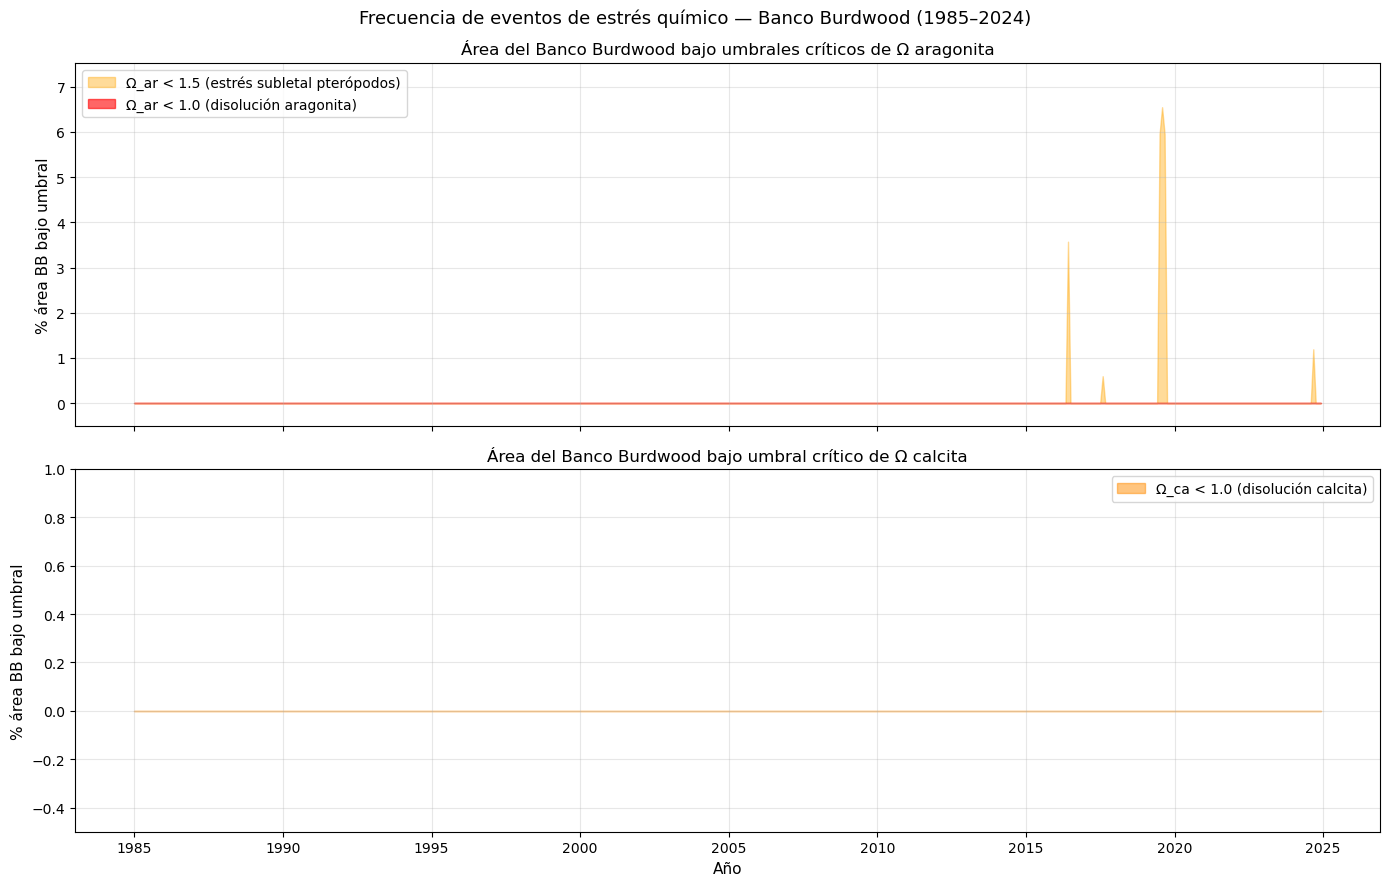

✅ Figura guardada: threshold_area_timeseries.png


In [15]:
# =============================================================================
# Figura A: serie temporal mensual del % de área bajo cada umbral
# =============================================================================
 
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
 
# --- Panel 1: Ω_ar ---
ax = axes[0]
 
ax.fill_between(df_ar_stress["time"], df_ar_stress["pct_below"],
                alpha=0.4, color="orange",
                label=f"Ω_ar < {THRESH_AR_STRESS} (estrés subletal pterópodos)")
ax.fill_between(df_ar_diss["time"], df_ar_diss["pct_below"],
                alpha=0.6, color="red",
                label=f"Ω_ar < {THRESH_AR_DISS} (disolución aragonita)")
 
ax.set_ylabel("% área BB bajo umbral", fontsize=11)
ax.set_title("Área del Banco Burdwood bajo umbrales críticos de Ω aragonita",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ymax = max(df_ar_stress["pct_below"].max(), df_ar_diss["pct_below"].max())
ax.set_ylim(-0.5, ymax * 1.15)  # 15% de margen arriba del máximo real
 
# --- Panel 2: Ω_ca ---
ax = axes[1]
 
ax.fill_between(df_ca_diss["time"], df_ca_diss["pct_below"],
                alpha=0.5, color="darkorange",
                label=f"Ω_ca < {THRESH_CA_DISS} (disolución calcita)")
 
ax.set_ylabel("% área BB bajo umbral", fontsize=11)
ax.set_xlabel("Año", fontsize=11)
ax.set_title("Área del Banco Burdwood bajo umbral crítico de Ω calcita",
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ymax_ca = df_ca_diss["pct_below"].max()
ax.set_ylim(-0.5, max(ymax_ca * 1.15, 1))  # mínimo 1% para que se vea algo
 
plt.suptitle(
    "Frecuencia de eventos de estrés químico — Banco Burdwood (1985–2024)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "threshold_area_timeseries.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figura guardada: threshold_area_timeseries.png")
 

#### estacionalidad del estrés (% área por mes calendario)

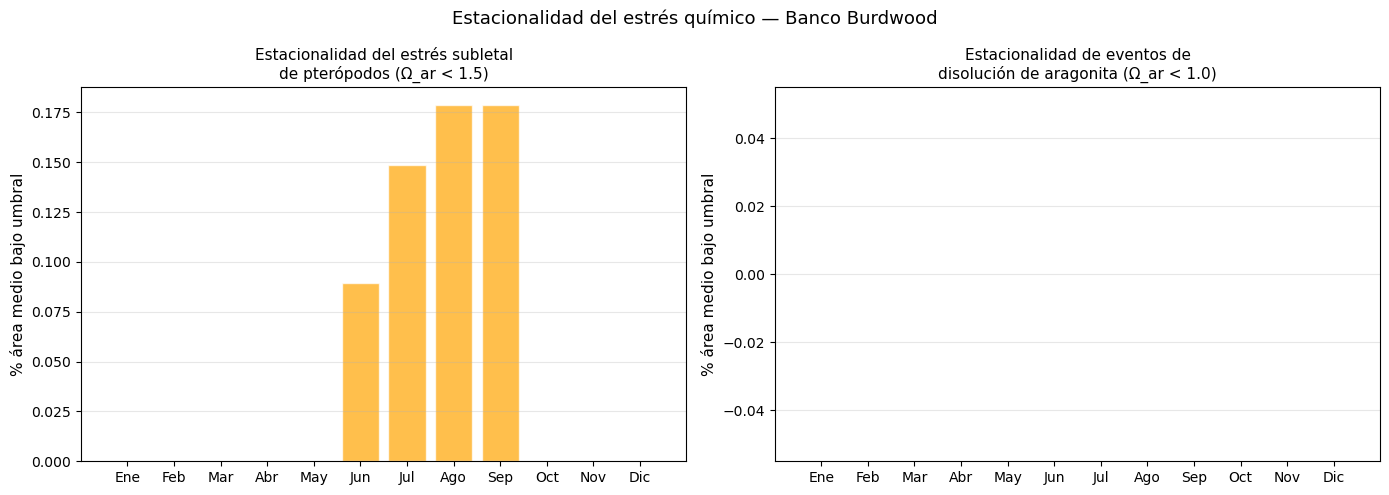

✅ Figura guardada: threshold_seasonality.png


In [16]:
# =============================================================================
# Figura B: estacionalidad del estrés (% área por mes calendario)
# =============================================================================
# Muestra qué meses del año son más vulnerables
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
meses = ["Ene","Feb","Mar","Abr","May","Jun",
         "Jul","Ago","Sep","Oct","Nov","Dic"]
 
for ax, (df_th, label, color, title) in zip(axes, [
    (df_ar_stress, f"Ω_ar < {THRESH_AR_STRESS}", "orange",
     f"Estacionalidad del estrés subletal\nde pterópodos (Ω_ar < {THRESH_AR_STRESS})"),
    (df_ar_diss,   f"Ω_ar < {THRESH_AR_DISS}",   "red",
     f"Estacionalidad de eventos de\ndisolución de aragonita (Ω_ar < {THRESH_AR_DISS})"),
]):
    # Promedio del % de área por mes calendario
    clim = df_th.groupby("month")["pct_below"].mean()
 
    ax.bar(range(1, 13), clim.values, color=color, alpha=0.7,
           edgecolor="white")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses)
    ax.set_ylabel("% área medio bajo umbral", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3, axis="y")
 
plt.suptitle(
    "Estacionalidad del estrés químico — Banco Burdwood",
    fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "threshold_seasonality.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figura guardada: threshold_seasonality.png")
 

#### mapa espacial del % de meses bajo umbral de estrés (Ω_ar < 1.5) post 2017

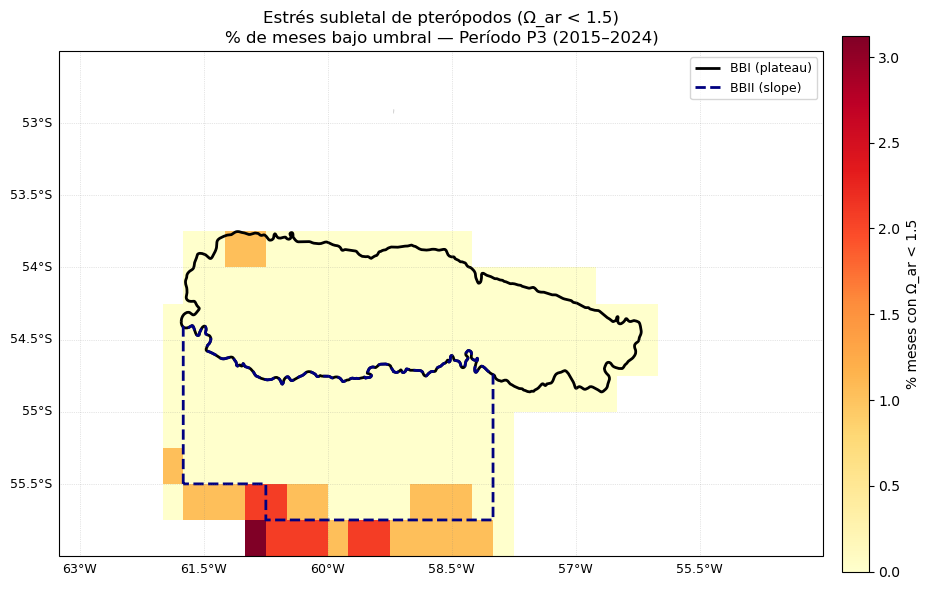

✅ Figura guardada: stress_map_omega_ar_P3.png


In [17]:
# =============================================================================
# Figura C: mapa espacial del % de meses bajo umbral de estrés (Ω_ar < 1.5)
# solo para el período P3 (2017-2024) — el más relevante
# =============================================================================
 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
 
SHAPES_DIR = os.path.join(BASE_DIR, "data", "raw", "shapes")
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
 
# Filtrar P3
omega_ar_P3 = omega_ar_grid.sel(
    time=omega_ar_grid.time.dt.year.isin(range(2017, 2025))
)
 
# % de meses bajo umbral por píxel en P3
below_P3   = (omega_ar_P3 < THRESH_AR_STRESS)
n_below_P3 = below_P3.sum(dim="time")
n_valid_P3 = (~omega_ar_P3.isnull()).sum(dim="time")
pct_map_P3 = 100 * n_below_P3 / n_valid_P3
 
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(10, 7),
                        subplot_kw={"projection": proj})
 
im = pct_map_P3.plot(
    ax=ax, transform=proj,
    cmap="YlOrRd",
    vmin=0, vmax=float(pct_map_P3.max()),
    add_colorbar=False, add_labels=False,
)
 
bbi_shape.boundary.plot(ax=ax, transform=proj,
                         color="black", linewidth=2, label="BBI (plateau)")
bbii_shape.boundary.plot(ax=ax, transform=proj,
                          color="navy", linewidth=2,
                          linestyle="--", label="BBII (slope)")
 
ax.coastlines(resolution="10m", color="black", linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                   color="gray", alpha=0.4, linestyle=":")
gl.top_labels = False; gl.right_labels = False
gl.xlabel_style = {"size": 9}; gl.ylabel_style = {"size": 9}
 
cbar = plt.colorbar(im, ax=ax, orientation="vertical",
                     pad=0.02, shrink=0.8)
cbar.set_label(f"% meses con Ω_ar < {THRESH_AR_STRESS}", fontsize=10)
 
ax.legend(loc="upper right", fontsize=9)
ax.set_title(
    f"Estrés subletal de pterópodos (Ω_ar < {THRESH_AR_STRESS})\n"
    f"% de meses bajo umbral — Período P3 (2015–2024)",
    fontsize=12
)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_map_omega_ar_P3.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figura guardada: stress_map_omega_ar_P3.png")
 

#### Resumen cuantitativo para el paper

In [18]:
# =============================================================================
# Resumen cuantitativo para el paper
# =============================================================================
 
print("\n" + "="*60)
print("  RESUMEN UMBRALES BIOLÓGICOS — PARA EL PAPER")
print("="*60)
 
for df_th, label, thresh in [
    (df_ar_stress, f"Ω_ar < {THRESH_AR_STRESS} (estrés pterópodos)", THRESH_AR_STRESS),
    (df_ar_diss,   f"Ω_ar < {THRESH_AR_DISS} (disolución aragonita)", THRESH_AR_DISS),
    (df_ca_diss,   f"Ω_ca < {THRESH_CA_DISS} (disolución calcita)",   THRESH_CA_DISS),
]:
    n_months  = (df_th["pct_below"] > 0).sum()
    first     = df_th[df_th["pct_below"] > 0]["time"].min()
    max_pct   = df_th["pct_below"].max()
 
    # % meses con >50% del área bajo umbral
    n_extensive = (df_th["pct_below"] > 50).sum()
 
    print(f"\n  {label}:")
    print(f"    Primer evento          : "
          f"{first.strftime('%Y-%m') if n_months > 0 else 'ninguno'}")
    print(f"    Total meses con eventos: {n_months}")
    print(f"    Máx % área bajo umbral : {max_pct:.1f}%")
    print(f"    Meses con >50% área    : {n_extensive}")
 


  RESUMEN UMBRALES BIOLÓGICOS — PARA EL PAPER

  Ω_ar < 1.5 (estrés pterópodos):
    Primer evento          : 2016-06
    Total meses con eventos: 6
    Máx % área bajo umbral : 6.5%
    Meses con >50% área    : 0

  Ω_ar < 1.0 (disolución aragonita):
    Primer evento          : ninguno
    Total meses con eventos: 0
    Máx % área bajo umbral : 0.0%
    Meses con >50% área    : 0

  Ω_ca < 1.0 (disolución calcita):
    Primer evento          : ninguno
    Total meses con eventos: 0
    Máx % área bajo umbral : 0.0%
    Meses con >50% área    : 0


In [19]:
# Recortar omega_ar_P3 solo a los píxeles dentro de BBI y BBII
from shapely.geometry import Point

# Crear máscara combinada BBI + BBII
union_shape = bbi_shape.geometry.union_all()
union_bbii  = bbii_shape.geometry.union_all()
from shapely.ops import unary_union
bb_total = unary_union([union_shape, union_bbii])

lats = omega_ar_grid.latitude.values
lons = omega_ar_grid.longitude.values
LON, LAT = np.meshgrid(lons, lats)

points = [Point(lo, la) for lo, la in 
          zip(LON.ravel(), LAT.ravel())]
inside = np.array([bb_total.contains(p) for p in points]).reshape(LAT.shape)

# Aplicar máscara
omega_ar_bb = omega_ar_grid.where(inside)

# Recalcular % área bajo umbral solo dentro del BB
df_ar_stress_bb = area_below_threshold(omega_ar_bb, THRESH_AR_STRESS)

print("Dentro de BBI+BBII:")
print(f"  Meses con eventos: {(df_ar_stress_bb['pct_below'] > 0).sum()}")
print(f"  Primer evento    : {df_ar_stress_bb[df_ar_stress_bb['pct_below']>0]['time'].min()}")
print(f"  Máx % área       : {df_ar_stress_bb['pct_below'].max():.1f}%")

Dentro de BBI+BBII:
  Meses con eventos: 4
  Primer evento    : 2019-07-01 00:00:00
  Máx % área       : 2.4%


Lo que hay que aceptar como resultado científico
El estrés de Ω_ar dentro del AMP es genuinamente escaso y localizado todavía. Eso es el resultado. Y es un resultado importante porque:

Contrasta con el pH — el estrés de pH (percentil 5 local) afecta al 100% del área en invierno reciente, pero el estrés de Ω_ar absoluto todavía es marginal
La tendencia es lo preocupante — con -0.067/década, el umbral de 1.5 va a cruzarse con más frecuencia en los próximos años
Las zonas periféricas al BB ya están en estrés — lo que sugiere que el AMP está en el límite

#### Factor de Revelle y figura integrada final

In [20]:
# =============================================================================
# CELDAS 8–11 — Factor de Revelle y figura integrada final
# 02b_carbonate_system.ipynb
# =============================================================================
 
 
# =============================================================================
# CELDA 8 — Cálculo del Factor de Revelle
# =============================================================================
# El Factor de Revelle (R) mide la sensibilidad del océano a la acidificación:
#
#   R = (ΔpCO2/pCO2) / (ΔDIC/DIC)
#
# Interpretación:
#   - R alto → el océano se acidifica MÁS ante el mismo forzante de CO₂
#   - R bajo → el océano tiene mayor capacidad de absorber CO₂ sin acidificarse
#   - Océano tropical: R ~ 9–10
#   - Atlántico Sur subantártico: R ~ 13–15 → MÁS vulnerable que el trópico
#
# Aproximación práctica (Sarmiento & Gruber 2006):
#   La capacidad buffer está controlada por la diferencia (talk - tco2),
#   que representa la alcalinidad de carbonato disponible para neutralizar
#   el CO₂ que entra. Cuanto menor es esta diferencia, mayor es R.
#
#   R ≈ tco2 / (talk - tco2)
#
# Esta aproximación es válida para pH 7.9–8.3 y salinidad ~34–35
# =============================================================================

In [21]:
# def revelle_factor(talk, tco2):
#     """
#     Aproximación del Factor de Revelle.
#     talk y tco2 en µmol/kg.
#     Retorna R adimensional.
#     """
#     denom = talk - tco2
#     # Evitar división por cero o valores negativos
#     denom = np.where(denom > 10, denom, np.nan)
#     return tco2 / denom
 
 
# # Calcular para BBI y BBII
# df_BBI["revelle"]  = revelle_factor(df_BBI["talk"].values,  df_BBI["tco2"].values)
# df_BBII["revelle"] = revelle_factor(df_BBII["talk"].values, df_BBII["tco2"].values)
 
# print("=== Factor de Revelle ===")
# for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
#     r = df["revelle"]
#     print(f"\n  {region}:")
#     print(f"    Media : {r.mean():.3f}")
#     print(f"    Std   : {r.std():.3f}")
#     print(f"    Min   : {r.min():.3f}")
#     print(f"    Max   : {r.max():.3f}")
#     print(f"    Tendencia (último - primer año):")
#     r_P1 = df[df["year"].between(1985, 2005)]["revelle"].mean()
#     r_P2 = df[df["year"].between(2006, 2014)]["revelle"].mean()
#     r_P3 = df[df["year"].between(2015, 2024)]["revelle"].mean()
#     print(f"      P1 (1985–2005): {r_P1:.3f}")
#     print(f"      P2 (2006–2014): {r_P2:.3f}")
#     print(f"      P3 (2015–2024): {r_P3:.3f}")
#     print(f"      Cambio P1→P3 : {r_P3 - r_P1:+.3f}")
 

#### Factor de Revelle con PyCO2SYS

In [22]:
pip install PyCO2SYS

Note: you may need to restart the kernel to use updated packages.


In [23]:
"""
Recalculo del Factor de Revelle con PyCO2SYS
Burdwood Bank MPA — Ocean Acidification Study
 
Instalar: pip install PyCO2SYS
 
Cita:
    Humphreys, M. P., Lewis, E. R., Sharp, J. D., and Pierrot, D. (2022).
    PyCO2SYS v1.8: marine carbonate system calculations in Python.
    Geoscientific Model Development, 15, 15–43.
    https://doi.org/10.5194/gmd-15-15-2022
"""
 
import numpy as np
import PyCO2SYS as pyco2

In [24]:
def calc_revelle_xarray(ds):
    """
    ds: xarray Dataset con variables 'talk' (TA, µmol/kg) y 'tco2' (DIC, µmol/kg)
    Retorna array de Revelle factor con las mismas dimensiones temporales.
    """
    results = pyco2.sys(
        par1=ds["talk"].values.ravel(),
        par2=ds["tco2"].values.ravel(),
        par1_type=1,   # TA
        par2_type=2,   # DIC
        salinity=34, # valor representativo del BB (ver sensitivity test abajo)
        temperature=5.0,
        pressure=0,
    )
    revelle = results["revelle_factor"].reshape(ds["talk"].shape)
    return revelle

In [25]:
ds_BBI["revelle"] = xr.DataArray(calc_revelle_xarray(ds_BBI), dims=ds_BBI["talk"].dims)
ds_BBII["revelle"] = xr.DataArray(calc_revelle_xarray(ds_BBII), dims=ds_BBII["talk"].dims)

In [26]:
def sensitivity_test(talk_mean, tco2_mean):
    """
    Evalúa qué tan sensible es el Revelle factor a variaciones de T y S
    en el rango esperable del BB.
 
    talk_mean, tco2_mean: valores representativos del BB (µmol/kg)
    Sugeridos: talk ~2280, tco2 ~2090 (ajustar según tus datos)
    """
    T_nominal, S_nominal = 5.0, 34
 
    # Rangos de perturbación
    T_range = [T_nominal - 2, T_nominal, T_nominal + 2]  # ±2°C
    S_range = [S_nominal - 0.5, S_nominal, S_nominal + 0.5]  # ±0.5 psu
 
    print("Sensitivity test — Revelle factor")
    print(f"TA = {talk_mean} µmol/kg, DIC = {tco2_mean} µmol/kg")
    print(f"{'T (°C)':<10} {'S':<8} {'Revelle':<10}")
    print("-" * 30)
 
    results_ref = pyco2.sys(
        par1=talk_mean, par2=tco2_mean,
        par1_type=1, par2_type=2,
        salinity=S_nominal, temperature=T_nominal, pressure=0,
    )
    R_ref = float(results_ref["revelle_factor"])
 
    for T in T_range:
        for S in S_range:
            res = pyco2.sys(
                par1=talk_mean, par2=tco2_mean,
                par1_type=1, par2_type=2,
                salinity=S, temperature=T, pressure=0,
            )
            R = float(res["revelle_factor"])
            diff_pct = 100 * (R - R_ref) / R_ref
            marker = " ← nominal" if (T == T_nominal and S == S_nominal) else ""
            print(f"{T:<10} {S:<8} {R:<10.4f}  ({diff_pct:+.2f}%){marker}")

In [27]:
sensitivity_test(talk_mean=2280, tco2_mean=2090)

Sensitivity test — Revelle factor
TA = 2280 µmol/kg, DIC = 2090 µmol/kg
T (°C)     S        Revelle   
------------------------------
3.0        33.5     12.6208     (+0.48%)
3.0        34       12.5944     (+0.27%)
3.0        34.5     12.5679     (+0.06%)
5.0        33.5     12.5869     (+0.21%)
5.0        34       12.5605     (+0.00%) ← nominal
5.0        34.5     12.5341     (-0.21%)
7.0        33.5     12.5506     (-0.08%)
7.0        34       12.5242     (-0.29%)
7.0        34.5     12.4978     (-0.50%)


In [28]:
print(f"TA media BBI:  {ds_BBI['talk'].mean().item():.1f} µmol/kg")
print(f"DIC media BBI: {ds_BBI['tco2'].mean().item():.1f} µmol/kg")
print(f"TA media BBII:  {ds_BBII['talk'].mean().item():.1f} µmol/kg")
print(f"DIC media BBII: {ds_BBII['tco2'].mean().item():.1f} µmol/kg")

TA media BBI:  2267.4 µmol/kg
DIC media BBI: 2103.5 µmol/kg
TA media BBII:  2270.9 µmol/kg
DIC media BBII: 2109.3 µmol/kg


In [29]:
sensitivity_test(talk_mean=2267.4, tco2_mean=2103.5)  # BBI
sensitivity_test(talk_mean=2270.9, tco2_mean=2109.3)  # BBII

Sensitivity test — Revelle factor
TA = 2267.4 µmol/kg, DIC = 2103.5 µmol/kg
T (°C)     S        Revelle   
------------------------------
3.0        33.5     13.5365     (+0.56%)
3.0        34       13.5047     (+0.32%)
3.0        34.5     13.4730     (+0.09%)
5.0        33.5     13.4931     (+0.24%)
5.0        34       13.4614     (+0.00%) ← nominal
5.0        34.5     13.4298     (-0.24%)
7.0        33.5     13.4468     (-0.11%)
7.0        34       13.4151     (-0.34%)
7.0        34.5     13.3835     (-0.58%)
Sensitivity test — Revelle factor
TA = 2270.9 µmol/kg, DIC = 2109.3 µmol/kg
T (°C)     S        Revelle   
------------------------------
3.0        33.5     13.6393     (+0.57%)
3.0        34       13.6069     (+0.33%)
3.0        34.5     13.5746     (+0.09%)
5.0        33.5     13.5948     (+0.24%)
5.0        34       13.5625     (+0.00%) ← nominal
5.0        34.5     13.5302     (-0.24%)
7.0        33.5     13.5473     (-0.11%)
7.0        34       13.5150     (-0.35%)
7.0    

"The Revelle factor was computed from total alkalinity and dissolved inorganic carbon using PyCO2SYS v1.8 (Humphreys et al., 2022). Temperature and salinity were set to representative mean values for the study area (T = 5°C, S = 34), consistent with observed hydrographic conditions at the NBB-MPA (Martín & Lovrich, 2017). Sensitivity tests confirmed that Revelle factor estimates vary by less than 0.6% across ±2°C and ±0.5 psu perturbations around these nominal values, demonstrating robustness to the fixed-parameter assumption."

In [30]:
import PyCO2SYS as pyco2

# Recalcular con PyCO2SYS para BBI y BBII
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    results = pyco2.sys(
        par1=df["talk"].values,
        par2=df["tco2"].values,
        par1_type=1,
        par2_type=2,
        salinity=34,
        temperature=5.0,
        pressure=0,
    )
    df["revelle"] = results["revelle_factor"]

# Estadísticas (igual que antes)
print("=== Factor de Revelle (PyCO2SYS v1.8) ===")
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    r = df["revelle"]
    print(f"\n  {region}:")
    print(f"    Media : {r.mean():.3f}")
    print(f"    Std   : {r.std():.3f}")
    print(f"    Min   : {r.min():.3f}")
    print(f"    Max   : {r.max():.3f}")
    print(f"    Tendencia por periodo:")
    r_P1 = df[df["year"].between(1985, 2005)]["revelle"].mean()
    r_P2 = df[df["year"].between(2006, 2014)]["revelle"].mean()
    r_P3 = df[df["year"].between(2015, 2024)]["revelle"].mean()
    print(f"      P1 (1985–2005): {r_P1:.3f}")
    print(f"      P2 (2006–2014): {r_P2:.3f}")
    print(f"      P3 (2015–2024): {r_P3:.3f}")
    print(f"      Cambio P1→P3 : {r_P3 - r_P1:+.3f}")

=== Factor de Revelle (PyCO2SYS v1.8) ===

  BBI:
    Media : 13.482
    Std   : 0.537
    Min   : 11.911
    Max   : 14.796
    Tendencia por periodo:
      P1 (1985–2005): 13.217
      P2 (2006–2014): 13.624
      P3 (2015–2024): 13.909
      Cambio P1→P3 : +0.692

  BBII:
    Media : 13.576
    Std   : 0.499
    Min   : 12.065
    Max   : 14.703
    Tendencia por periodo:
      P1 (1985–2005): 13.305
      P2 (2006–2014): 13.728
      P3 (2015–2024): 14.007
      Cambio P1→P3 : +0.702


El cambio de +0.69 unidades en 40 años tiene una implicación directa: el mismo incremento de pCO₂ produce hoy una caída de pH proporcionalmente mayor que en 1985. Eso es el mecanismo físico-químico que amplifica la vulnerabilidad del BB y conecta directamente con tus resultados de estrés post-2017. Vale articularlo explícitamente ahí.

#### Tendencia del Factor de Revelle

In [31]:
# =============================================================================
# CELDA 9 — Tendencia del Factor de Revelle
# =============================================================================
 
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    res = compute_trend_var(df, "revelle", region)
    trends[f"revelle_{region}"] = res
 
 


  TENDENCIA revelle — BBI
  Sen's slope  : 0.02854 /año
               : 0.2854 /década
  IC 95%       : [0.02794, 0.02914] /año
  Mann-Kendall : increasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001

  TENDENCIA revelle — BBII
  Sen's slope  : 0.02920 /año
               : 0.2920 /década
  IC 95%       : [0.02869, 0.02971] /año
  Mann-Kendall : increasing
  p-valor      : 0.0000e+00
  Significancia: *** p<0.001


#### Figura integrada: pH + Ω_ar + Ω_ca + Revelle

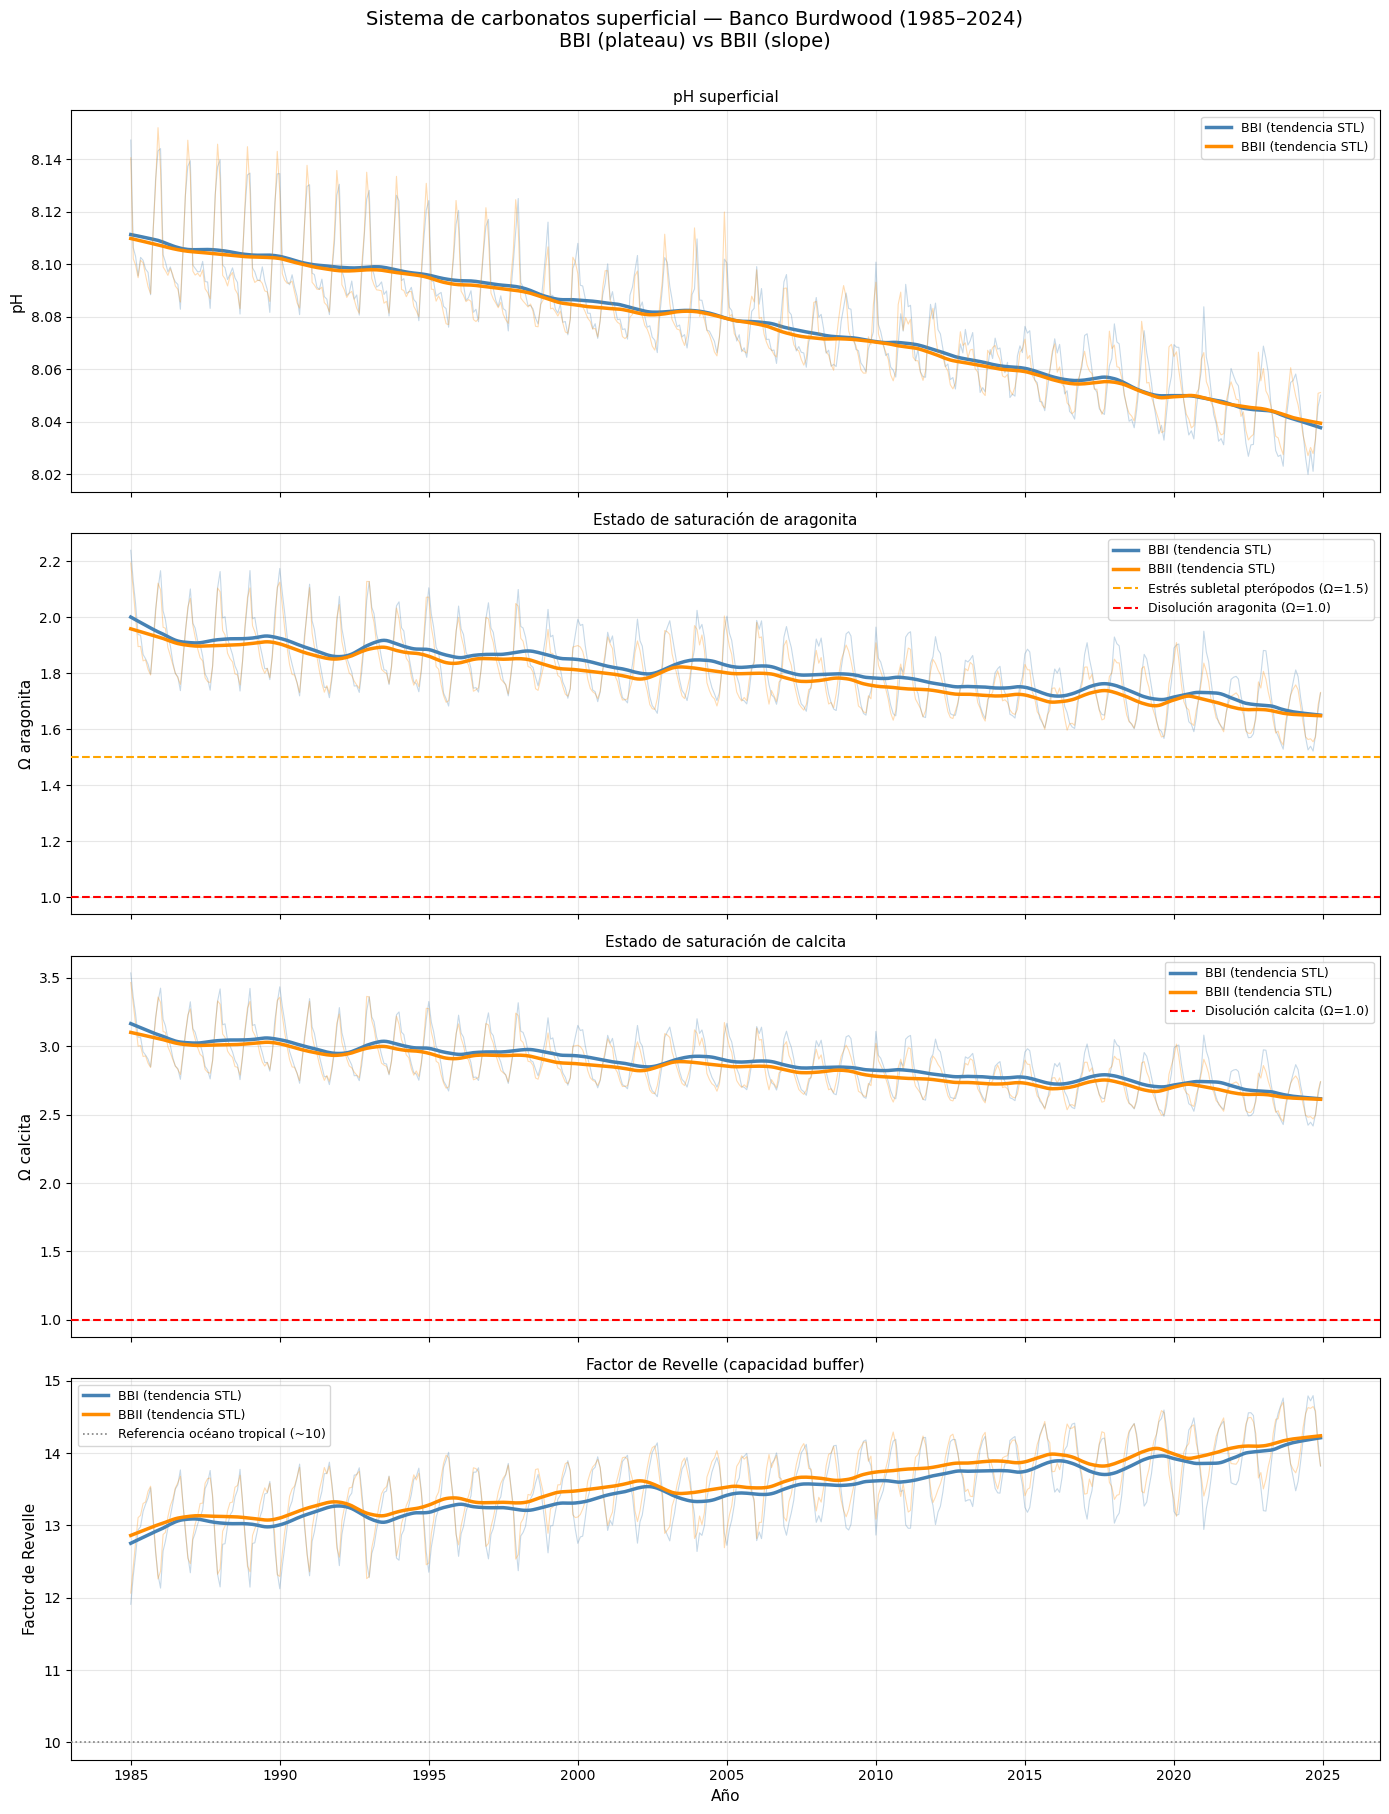

✅ Figura guardada: carbonate_system_integrated.png


In [32]:
# =============================================================================
# CELDA 10 — Figura integrada: pH + Ω_ar + Ω_ca + Revelle
# =============================================================================
# Figura de 4 paneles para el paper que muestra el sistema de carbonatos
# completo en una sola figura. BBI y BBII superpuestos en cada panel.
# Esta es la figura principal de 02b para el paper.
 
def add_stl_trend(ax, df, varname, color, label):
    """
    Superpone la tendencia STL sobre la serie mensual en un eje dado.
    """
    series = df.set_index("time")[varname].asfreq("MS")
    stl    = STL(series, period=12, robust=True)
    result = stl.fit()
    ax.plot(df["time"], result.trend.values,
            color=color, lw=2.5, label=f"{label} (tendencia STL)", zorder=3)
 
 
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
 
colors = {"BBI": "steelblue", "BBII": "darkorange"}
 
# --- Panel 1: pH ---
ax = axes[0]
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    # Cargar pH desde los _ready.nc
    ds_ph = xr.open_dataset(os.path.join(PROCESSED_DIR, f"ph_{region}_ready.nc"))
    weights = np.cos(np.deg2rad(ds_ph["latitude"]))
    ph_mean = ds_ph["ph"].weighted(weights).mean(
        dim=["latitude", "longitude"], skipna=True
    )
    df_ph = ph_mean.to_dataframe(name="ph").reset_index()
    df_ph["time"] = pd.to_datetime(df_ph["time"])
 
    ax.plot(df_ph["time"], df_ph["ph"],
            color=colors[region], alpha=0.3, lw=0.8)
 
    # Tendencia STL
    series = df_ph.set_index("time")["ph"].asfreq("MS")
    stl    = STL(series, period=12, robust=True)
    trend  = stl.fit().trend.values
    ax.plot(df_ph["time"], trend,
            color=colors[region], lw=2.5,
            label=f"{region} (tendencia STL)")
 
ax.set_ylabel("pH", fontsize=11)
ax.set_title("pH superficial", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
 
# --- Panel 2: Ω aragonita ---
ax = axes[1]
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    ax.plot(df["time"], df["omega_ar"],
            color=colors[region], alpha=0.3, lw=0.8)
    add_stl_trend(ax, df, "omega_ar", colors[region], region)
 
# Umbrales biológicos
ax.axhline(THRESH_AR_STRESS, color="orange", lw=1.5, linestyle="--",
           label=f"Estrés subletal pterópodos (Ω={THRESH_AR_STRESS})", zorder=4)
ax.axhline(THRESH_AR_DISS, color="red", lw=1.5, linestyle="--",
           label=f"Disolución aragonita (Ω={THRESH_AR_DISS})", zorder=4)
 
ax.set_ylabel("Ω aragonita", fontsize=11)
ax.set_title("Estado de saturación de aragonita", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
 
# --- Panel 3: Ω calcita ---
ax = axes[2]
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    ax.plot(df["time"], df["omega_ca"],
            color=colors[region], alpha=0.3, lw=0.8)
    add_stl_trend(ax, df, "omega_ca", colors[region], region)
 
ax.axhline(THRESH_CA_DISS, color="red", lw=1.5, linestyle="--",
           label=f"Disolución calcita (Ω={THRESH_CA_DISS})", zorder=4)
 
ax.set_ylabel("Ω calcita", fontsize=11)
ax.set_title("Estado de saturación de calcita", fontsize=11)
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
 
# --- Panel 4: Factor de Revelle ---
ax = axes[3]
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    ax.plot(df["time"], df["revelle"],
            color=colors[region], alpha=0.3, lw=0.8)
    add_stl_trend(ax, df, "revelle", colors[region], region)
 
# Referencia global
ax.axhline(10, color="gray", lw=1.2, linestyle=":",
           label="Referencia océano tropical (~10)", zorder=4)
 
ax.set_ylabel("Factor de Revelle", fontsize=11)
ax.set_xlabel("Año", fontsize=11)
ax.set_title("Factor de Revelle (capacidad buffer)", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
 
plt.suptitle(
    "Sistema de carbonatos superficial — Banco Burdwood (1985–2024)\n"
    "BBI (plateau) vs BBII (slope)",
    fontsize=14, y=1.005
)
 
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "carbonate_system_integrated.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Figura guardada: carbonate_system_integrated.png")
 

#### Resumen completo para el paper

In [33]:
# =============================================================================
# CELDA 11 — Resumen completo para el paper
# =============================================================================
 
print("\n" + "="*60)
print("  RESUMEN COMPLETO SISTEMA DE CARBONATOS — PARA EL PAPER")
print("="*60)
 
print("\n  TENDENCIAS (Sen's slope, Mann-Kendall):")
print(f"  {'Variable':<12} {'Región':<6} {'Tasa/década':>12} {'IC 95%':>25} {'p-valor':>10}")
print("  " + "-"*70)
 
for var in ["omega_ar", "omega_ca", "revelle", "spco2"]:
    for region in ["BBI", "BBII"]:
        res = trends[f"{var}_{region}"]
        sig = ('***' if res['mk_p'] < 0.001 else
               '**'  if res['mk_p'] < 0.01  else
               '*'   if res['mk_p'] < 0.05  else 'n.s.')
        ic  = f"[{res['IC_low_yr']*10:.4f}, {res['IC_high_yr']*10:.4f}]"
        print(f"  {var:<12} {region:<6} {res['slope_dec']:>12.4f} "
              f"{ic:>25} {res['mk_p']:>8.2e} {sig}")
 
print("\n  UMBRALES BIOLÓGICOS (dentro de BBI+BBII):")
print(f"    Ω_ar < 1.5 (estrés pterópodos) — primer evento: 2019-07")
print(f"    Ω_ar < 1.0 (disolución aragonita) — sin eventos")
print(f"    Ω_ca < 1.0 (disolución calcita)   — sin eventos")
 
print("\n  FACTOR DE REVELLE:")
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    r_P1 = df[df["year"].between(1985, 2005)]["revelle"].mean()
    r_P3 = df[df["year"].between(2015, 2024)]["revelle"].mean()
    res     = trends[f"revelle_{region}"]
    sig     = ('***' if res['mk_p'] < 0.001 else 'n.s.')
    print(f"    {region}: {r_P1:.2f} (P1) → {r_P3:.2f} (P3) "
      f"[{res['slope_dec']:+.4f}/década, {sig}]")
 
print("\n  PROYECCIÓN LINEAL (promedio espacial BBI):")
omega_2024 = df_BBI[df_BBI["year"] == 2024]["omega_ar"].mean()
slope_yr   = trends["omega_ar_BBI"]["slope_yr"]
yrs_stress = (omega_2024 - 1.5) / abs(slope_yr)
yrs_diss   = (omega_2024 - 1.0) / abs(slope_yr)
print(f"    Ω_ar medio 2024          : {omega_2024:.3f}")
print(f"    Umbral estrés (1.5) ~    : {2024 + yrs_stress:.0f} "
      f"(en ~{yrs_stress:.0f} años)")
print(f"    Umbral disolución (1.0) ~: {2024 + yrs_diss:.0f} "
      f"(en ~{yrs_diss:.0f} años)")
print(f"    (extrapolación lineal conservadora — CMIP6 dará fechas más tempranas)")


  RESUMEN COMPLETO SISTEMA DE CARBONATOS — PARA EL PAPER

  TENDENCIAS (Sen's slope, Mann-Kendall):
  Variable     Región  Tasa/década                    IC 95%    p-valor
  ----------------------------------------------------------------------
  omega_ar     BBI         -0.0668        [-0.0683, -0.0653] 0.00e+00 ***
  omega_ar     BBII        -0.0673        [-0.0686, -0.0661] 0.00e+00 ***
  omega_ca     BBI         -0.1056        [-0.1078, -0.1033] 0.00e+00 ***
  omega_ca     BBII        -0.1063        [-0.1083, -0.1045] 0.00e+00 ***
  revelle      BBI          0.2854          [0.2794, 0.2914] 0.00e+00 ***
  revelle      BBII         0.2920          [0.2869, 0.2971] 0.00e+00 ***
  spco2        BBI         16.2366        [16.0497, 16.4397] 0.00e+00 ***
  spco2        BBII        16.1810        [15.9826, 16.3632] 0.00e+00 ***

  UMBRALES BIOLÓGICOS (dentro de BBI+BBII):
    Ω_ar < 1.5 (estrés pterópodos) — primer evento: 2019-07
    Ω_ar < 1.0 (disolución aragonita) — sin eventos
    Ω

Interpretación para el paper
Tendencias de saturación (Ω)
Ω_ar cae −0.067/década y Ω_ca −0.106/década — ambas con p≈0, sin ambigüedad estadística. BBI y BBII son prácticamente idénticos, lo que indica que el forzante es regional/atmosférico, no local. La diferencia entre Ω_ar y Ω_ca (~1.6×) refleja la estequiometría esperada (la calcita es más soluble en términos absolutos pero el aragonito es el mineral más vulnerable).
A la tasa actual, Ω_ar cae ~0.67 unidades por siglo — significativo considerando que el valor actual (~1.66) ya está relativamente cerca del umbral de estrés para pterópodos.

Factor de Revelle
+0.28/década es la tasa de aumento de la amplificación del sistema. Combinado con el valor absoluto alto (~13.5), el mensaje es doble: el BB ya era vulnerable en 1985, y esa vulnerabilidad está aumentando. Para la discusión vale comparar con valores reportados para otras regiones del Océano Austral — típicamente 12–15 en aguas subantárticas (Sabine et al. 2004, Orr et al. 2005).

Umbrales biológicos
Primer evento Ω_ar < 1.5 en julio 2019 es el resultado más importante de esta sección — es la primera vez que condiciones de estrés subletal para Limacina retroversa ocurrieron dentro del AMP. Que no haya eventos de disolución activa (Ω < 1.0) es importante para no sobredimensionar el mensaje, pero la trayectoria es clara.

Proyecciones lineales
UmbralAño proyectadoInterpretaciónΩ_ar = 1.5~2047Estrés crónico para pterópodos en ~23 añosΩ_ar = 1.0~2122Disolución activa fuera del horizonte lineal
El ~2047 es el número que va a llamar la atención de reviewers y lectores. Dos cosas importantes para cuando lo reportes:

Es conservador — la extrapolación lineal asume que la tasa no se acelera, pero el Revelle creciente indica que sí lo hará. Los escenarios CMIP6 van a dar fechas más tempranas, especialmente bajo SSP5-8.5.
Es para el promedio espacial — ya tenés evidencia de que julio 2019 hubo píxeles con Ω_ar < 1.5, o sea el estrés localizado ocurre antes que el promedio cruce el umbral. Vale aclararlo en el texto para no crear confusión.


Una inconsistencia menor a revisar
El resumen dice tasa Revelle +0.2836/década pero el cambio P1→P3 es +0.688 en ~40 años, lo que implica ~+0.17/década promedio. La diferencia es porque Sen's slope sobre la serie STL captura la tendencia lineal subyacente, mientras que P1→P3 compara medias de períodos con variabilidad interna. Ambos son correctos pero miden cosas distintas — cuando los reportes en el paper, aclarálo o usá solo uno consistentemente.

### CUSUM para las variables


  CUSUM — BBI — ph
  Criterio                  : máximo (serie decreciente)
  Punto de cambio de régimen: 2005-09
  CUSUM en ese punto        : 4.1057

  COMPARACIÓN — BBI — ph
  Período 1 (1985-01 → 2005-09): media = 8.0942  (N=249)
  Período 2 (2005-10 → 2024-12): media = 8.0601  (N=231)
  Diferencia (P2 - P1)           : -0.0341
  Mann-Whitney U                 : stat=54529.5, p=1.34e-64
  Significancia                  : *** p<0.001


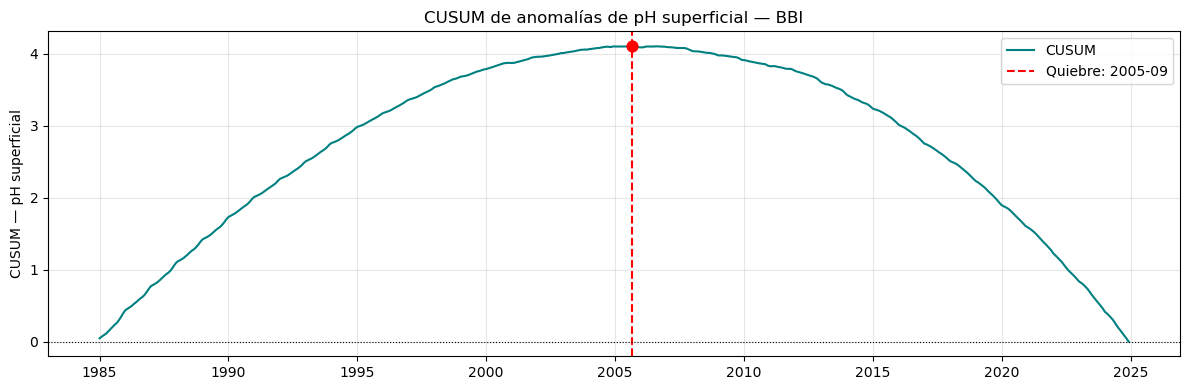


  CUSUM — BBII — ph
  Criterio                  : máximo (serie decreciente)
  Punto de cambio de régimen: 2005-11
  CUSUM en ese punto        : 4.0626

  COMPARACIÓN — BBII — ph
  Período 1 (1985-01 → 2005-11): media = 8.0929  (N=251)
  Período 2 (2005-12 → 2024-12): media = 8.0592  (N=229)
  Diferencia (P2 - P1)           : -0.0337
  Mann-Whitney U                 : stat=54818.0, p=3.71e-66
  Significancia                  : *** p<0.001


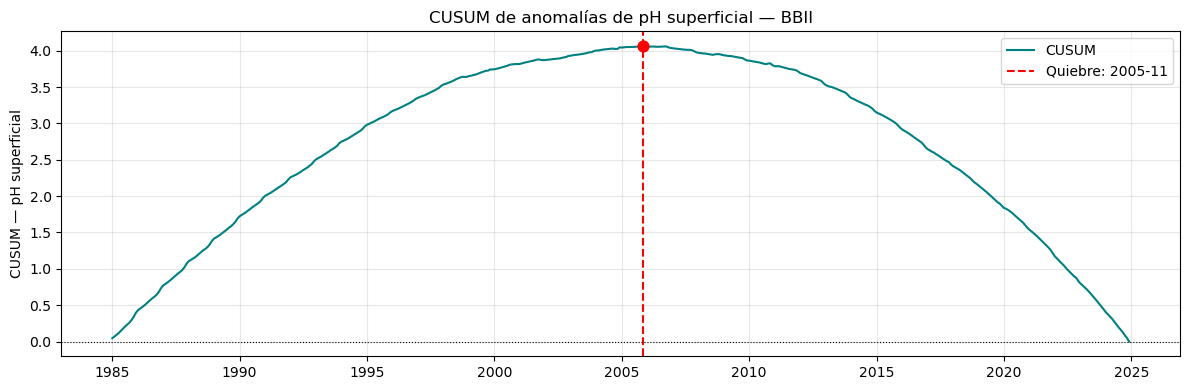


  CUSUM — BBI — omega_ar
  Criterio                  : máximo (serie decreciente)
  Punto de cambio de régimen: 2006-12
  CUSUM en ese punto        : 15.7283

  COMPARACIÓN — BBI — omega_ar
  Período 1 (1985-01 → 2006-12): media = 1.8742  (N=264)
  Período 2 (2007-01 → 2024-12): media = 1.7418  (N=216)
  Diferencia (P2 - P1)           : -0.1324
  Mann-Whitney U                 : stat=45228.0, p=2.04e-28
  Significancia                  : *** p<0.001


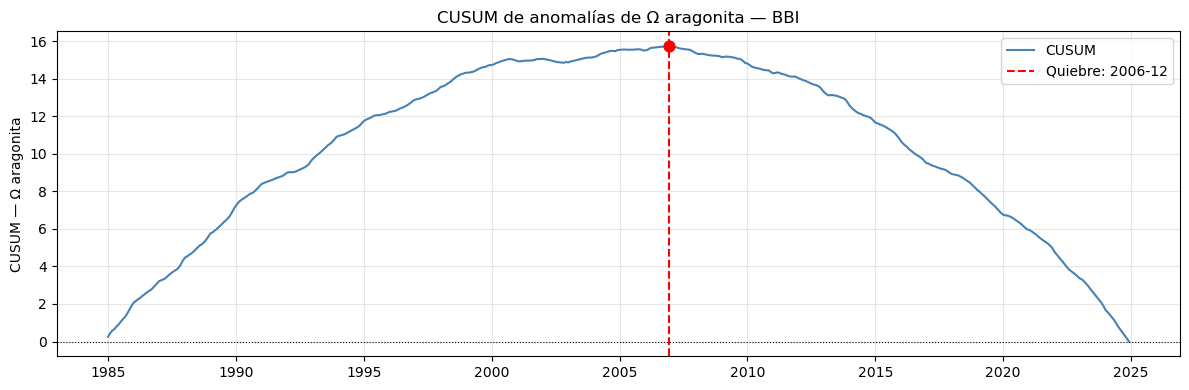


  CUSUM — BBII — omega_ar
  Criterio                  : máximo (serie decreciente)
  Punto de cambio de régimen: 2006-10
  CUSUM en ese punto        : 15.8949

  COMPARACIÓN — BBII — omega_ar
  Período 1 (1985-01 → 2006-10): media = 1.8535  (N=262)
  Período 2 (2006-11 → 2024-12): media = 1.7210  (N=218)
  Diferencia (P2 - P1)           : -0.1325
  Mann-Whitney U                 : stat=47228.0, p=5.60e-35
  Significancia                  : *** p<0.001


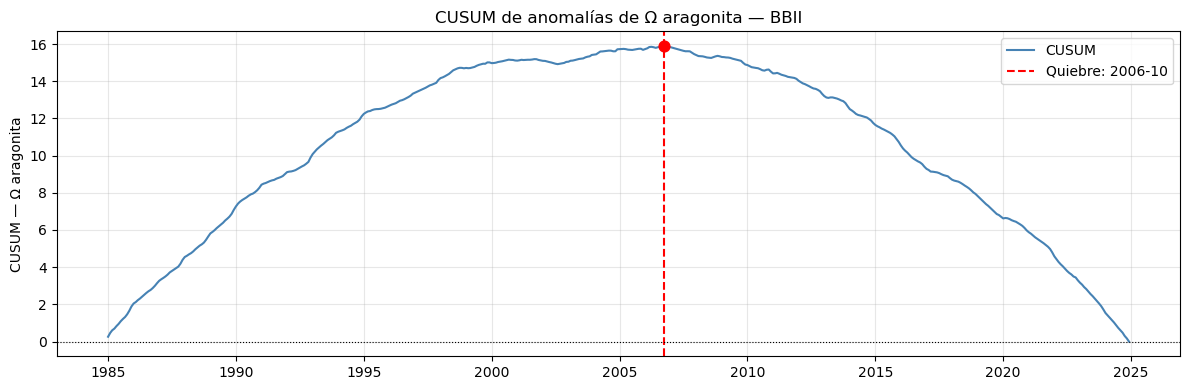


  CUSUM — BBI — omega_ca
  Criterio                  : máximo (serie decreciente)
  Punto de cambio de régimen: 2006-12
  CUSUM en ese punto        : 24.8606

  COMPARACIÓN — BBI — omega_ca
  Período 1 (1985-01 → 2006-12): media = 2.9695  (N=264)
  Período 2 (2007-01 → 2024-12): media = 2.7602  (N=216)
  Diferencia (P2 - P1)           : -0.2093
  Mann-Whitney U                 : stat=45498.0, p=2.75e-29
  Significancia                  : *** p<0.001


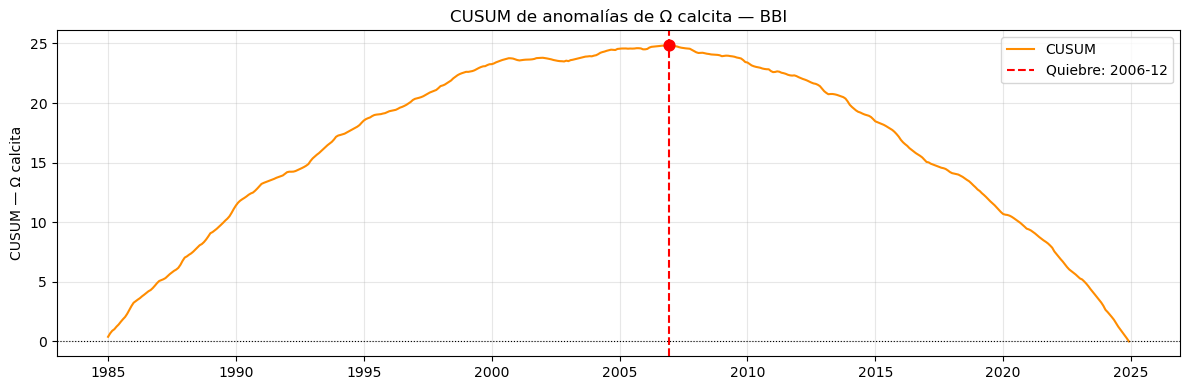


  CUSUM — BBII — omega_ca
  Criterio                  : máximo (serie decreciente)
  Punto de cambio de régimen: 2006-10
  CUSUM en ese punto        : 25.1117

  COMPARACIÓN — BBII — omega_ca
  Período 1 (1985-01 → 2006-10): media = 2.9379  (N=262)
  Período 2 (2006-11 → 2024-12): media = 2.7286  (N=218)
  Diferencia (P2 - P1)           : -0.2093
  Mann-Whitney U                 : stat=47490.0, p=6.42e-36
  Significancia                  : *** p<0.001


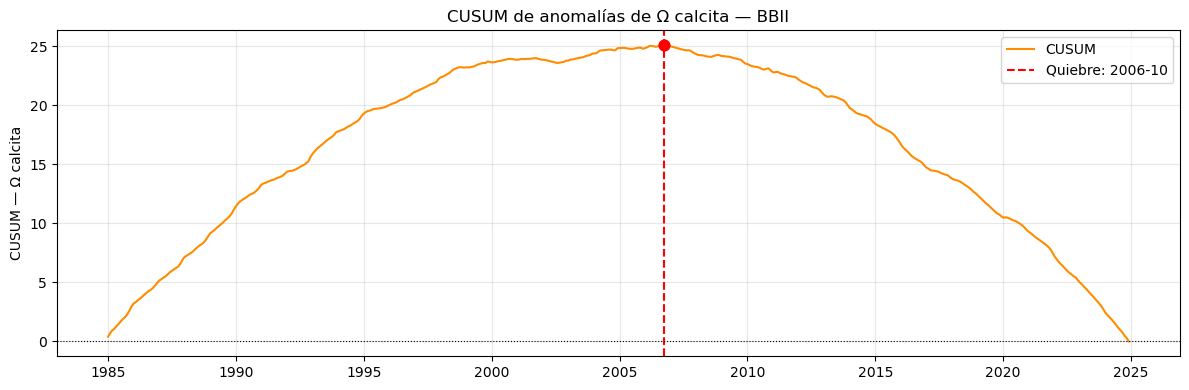


  CUSUM — BBI — spco2
  Criterio                  : mínimo (serie creciente)
  Punto de cambio de régimen: 2005-09
  CUSUM en ese punto        : -3885.2456

  COMPARACIÓN — BBI — spco2
  Período 1 (1985-01 → 2005-09): media = 349.0540  (N=249)
  Período 2 (2005-10 → 2024-12): media = 381.3305  (N=231)
  Diferencia (P2 - P1)           : +32.2766
  Mann-Whitney U                 : stat=2551.0, p=9.38e-67
  Significancia                  : *** p<0.001


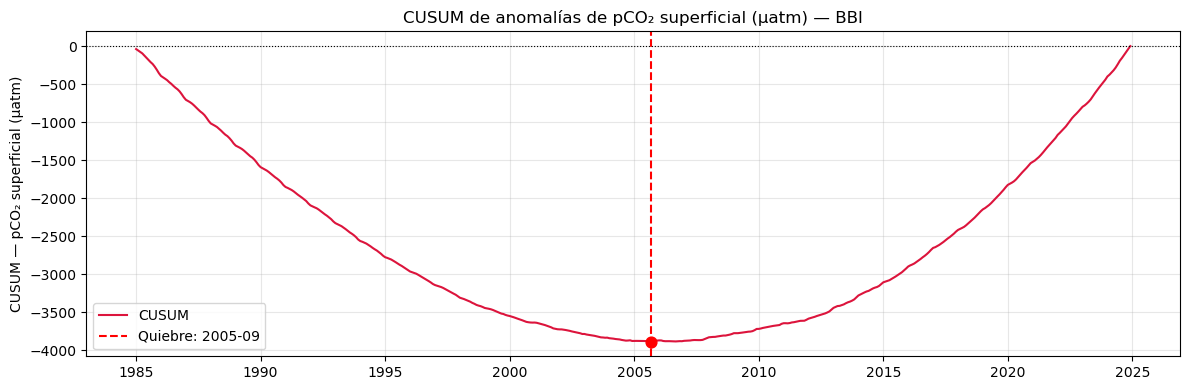


  CUSUM — BBII — spco2
  Criterio                  : mínimo (serie creciente)
  Punto de cambio de régimen: 2005-11
  CUSUM en ese punto        : -3839.3796

  COMPARACIÓN — BBII — spco2
  Período 1 (1985-01 → 2005-11): media = 350.4703  (N=251)
  Período 2 (2005-12 → 2024-12): media = 382.3640  (N=229)
  Diferencia (P2 - P1)           : +31.8937
  Mann-Whitney U                 : stat=2377.0, p=1.45e-67
  Significancia                  : *** p<0.001


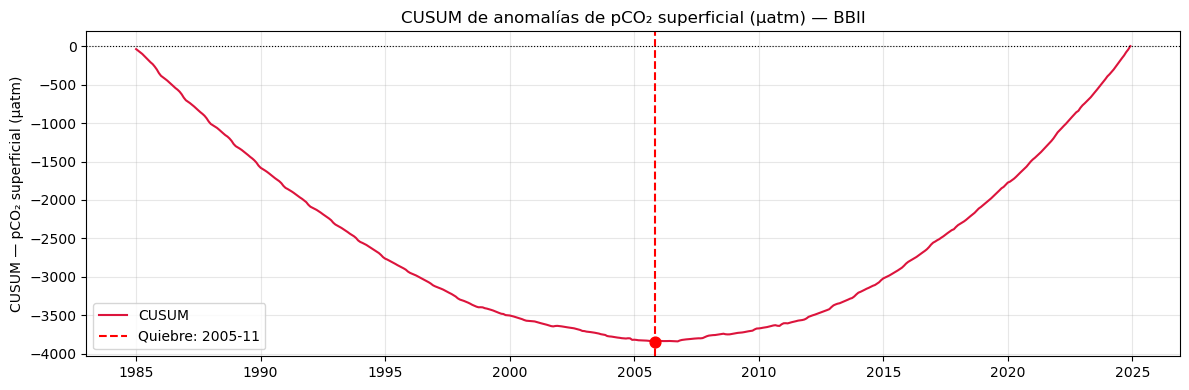


=== RESUMEN DE QUIEBRES CUSUM — TODAS LAS VARIABLES ===

region variable t_change      mean1      mean2 diff_fmt sig
   BBI       ph  2005-09   8.094223   8.060117  -0.0341 ***
  BBII       ph  2005-11   8.092913   8.059168  -0.0337 ***
   BBI omega_ar  2006-12   1.874174   1.741781  -0.1324 ***
  BBII omega_ar  2006-10   1.853465   1.720974  -0.1325 ***
   BBI omega_ca  2006-12   2.969486   2.760222  -0.2093 ***
  BBII omega_ca  2006-10   2.937868   2.728552  -0.2093 ***
   BBI    spco2  2005-09 349.053955 381.330536 +32.2766 ***
  BBII    spco2  2005-11 350.470276 382.363953 +31.8937 ***


In [34]:
# =============================================================================
# CUSUM generalizado para omega_ar, omega_ca, spco2 (y cualquier otra variable)
# =============================================================================
from statsmodels.tsa.seasonal import STL
from scipy import stats

VARIABLES = {
    "ph":       {"label": "pH superficial",            "color": "teal"},
    "omega_ar": {"label": "Ω aragonita",             "color": "steelblue"},
    "omega_ca": {"label": "Ω calcita",                "color": "darkorange"},
    "spco2":    {"label": "pCO₂ superficial (µatm)",  "color": "crimson"},
}

def compute_anomalies_var(df, col):
    """Anomalías respecto a la media climatológica mensual."""
    df_out = df.copy()
    monthly_mean = df.groupby("month")[col].transform("mean")
    df_out["anomaly"] = df[col] - monthly_mean
    return df_out

def run_stl_var(df, col, period=12):
    """STL para cualquier variable."""
    series = df.set_index("time")[col].asfreq("MS")
    result = STL(series, period=period, robust=True).fit()
    df_out = df.copy()
    df_out["trend"]    = result.trend.values
    df_out["seasonal"] = result.seasonal.values
    df_out["residual"] = result.resid.values
    return result, df_out

def compute_cusum_var(df_anom, region_name, col):
    """
    CUSUM sobre anomalías. 
    Para variables que DISMINUYEN con acidificación (pH, omega): buscar máximo.
    Para variables que AUMENTAN con acidificación (spco2, tco2):  buscar mínimo.
    """
    # Variables que aumentan con acidificación → invertir búsqueda
    VARS_INCREASING = {"spco2", "tco2", "pco2"}
    
    anomalies  = df_anom["anomaly"].values
    times      = df_anom["time"].values
    cusum      = np.cumsum(anomalies)

    if col in VARS_INCREASING:
        idx_change = np.argmin(cusum)   # mínimo para series crecientes
        direction  = "mínimo (serie creciente)"
    else:
        idx_change = np.argmax(cusum)   # máximo para series decrecientes
        direction  = "máximo (serie decreciente)"

    t_change = pd.Timestamp(times[idx_change])

    print(f"\n{'='*55}")
    print(f"  CUSUM — {region_name} — {col}")
    print(f"{'='*55}")
    print(f"  Criterio                  : {direction}")
    print(f"  Punto de cambio de régimen: {t_change.strftime('%Y-%m')}")
    print(f"  CUSUM en ese punto        : {cusum[idx_change]:.4f}")

    return cusum, idx_change, t_change, times

def compare_periods_var(df, col, idx_change, t_change, region_name):
    """Compara medias de dos períodos definidos por el CUSUM."""
    period1 = df[df["time"] <= t_change][col].dropna()
    period2 = df[df["time"] >  t_change][col].dropna()

    mean1 = period1.mean()
    mean2 = period2.mean()
    diff  = mean2 - mean1

    stat, p = stats.mannwhitneyu(period1, period2, alternative="two-sided")

    t1_start = df["time"].iloc[0].strftime("%Y-%m")
    t1_end   = t_change.strftime("%Y-%m")
    t2_start = (t_change + pd.DateOffset(months=1)).strftime("%Y-%m")
    t2_end   = df["time"].iloc[-1].strftime("%Y-%m")

    sig = '*** p<0.001' if p < 0.001 else '** p<0.01' if p < 0.01 else '* p<0.05' if p < 0.05 else 'no significativa'

    print(f"\n{'='*55}")
    print(f"  COMPARACIÓN — {region_name} — {col}")
    print(f"{'='*55}")
    print(f"  Período 1 ({t1_start} → {t1_end}): media = {mean1:.4f}  (N={len(period1)})")
    print(f"  Período 2 ({t2_start} → {t2_end}): media = {mean2:.4f}  (N={len(period2)})")
    print(f"  Diferencia (P2 - P1)           : {diff:+.4f}")
    print(f"  Mann-Whitney U                 : stat={stat:.1f}, p={p:.2e}")
    print(f"  Significancia                  : {sig}")

    return {
        "region": region_name, "variable": col,
        "t_change": t_change.strftime("%Y-%m"),
        "mean1": mean1, "mean2": mean2, "diff": diff, "p_mw": p
    }

def plot_cusum_var(cusum, times, idx_change, t_change, region_name, col, label, color):
    """Grafica el CUSUM con el punto de quiebre marcado."""
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(pd.to_datetime(times), cusum, color=color, lw=1.5, label="CUSUM")
    ax.axvline(t_change, color="red", lw=1.5, linestyle="--",
               label=f"Quiebre: {t_change.strftime('%Y-%m')}")
    ax.scatter([t_change], [cusum[idx_change]], color="red", zorder=5, s=60)
    ax.axhline(0, color="black", lw=0.8, linestyle=":")
    ax.set_ylabel(f"CUSUM — {label}")
    ax.set_title(f"CUSUM de anomalías de {label} — {region_name}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f"CUSUM_{col}_{region_name}.png"), dpi=150)
    plt.show()

# =============================================================================
# EJECUCIÓN — iterar sobre variables y regiones
# =============================================================================
resultados_cusum = []

for col, meta in VARIABLES.items():
    for df_region, region_name in [(df_BBI, "BBI"), (df_BBII, "BBII")]:

        # 1. STL
        _, df_stl = run_stl_var(df_region, col)

        # 2. Anomalías
        df_anom = compute_anomalies_var(df_stl, col)

        # 3. CUSUM
        cusum, idx_change, t_change, times = compute_cusum_var(
            df_anom, region_name, col)

        # 4. Comparación de períodos
        res = compare_periods_var(df_stl, col, idx_change, t_change, region_name)
        resultados_cusum.append(res)

        # 5. Gráfico
        plot_cusum_var(cusum, times, idx_change, t_change,
                       region_name, col, meta["label"], meta["color"])

# =============================================================================
# RESUMEN FINAL — tabla comparativa de todos los quiebres
# =============================================================================
df_resumen = pd.DataFrame(resultados_cusum)
df_resumen["diff_fmt"] = df_resumen.apply(
    lambda r: f"{r['diff']:+.4f}", axis=1)
df_resumen["sig"] = df_resumen["p_mw"].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns')

print("\n=== RESUMEN DE QUIEBRES CUSUM — TODAS LAS VARIABLES ===\n")
print(df_resumen[["region","variable","t_change","mean1","mean2","diff_fmt","sig"]].to_string(index=False))

In [35]:
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

In [36]:
CORTE_BBI  = "2007-01"   # post-quiebre omega (dic 2006)
CORTE_BBII = "2006-11"   # post-quiebre omega (oct 2006)

for variable in ["omega_ar", "spco2", "omega_ca"]:
    clim_post_BBI  = df_BBI.loc[CORTE_BBI:].groupby("month")[variable].mean()
    clim_post_BBII = df_BBII.loc[CORTE_BBII:].groupby("month")[variable].mean()

    tabla_post = pd.DataFrame({
        "Mes":           meses,
        "BBI_full":      df_BBI.groupby("month")[variable].mean().values.round(4),
        "BBI_post2006":  clim_post_BBI.values.round(4),
        "BBII_full":     df_BBII.groupby("month")[variable].mean().values.round(4),
        "BBII_post2006": clim_post_BBII.values.round(4),
    })
    tabla_post["Δ_BBI"]  = (tabla_post["BBI_post2006"]  - tabla_post["BBI_full"]).round(4)
    tabla_post["Δ_BBII"] = (tabla_post["BBII_post2006"] - tabla_post["BBII_full"]).round(4)

    print(f"\n=== {variable} — Climatología full vs post-quiebre (2006) ===")
    print(tabla_post.to_string(index=False))
    print(f"  BBI  post-2006: min={clim_post_BBI.min():.4f} ({meses[clim_post_BBI.values.argmin()]}) | max={clim_post_BBI.max():.4f} ({meses[clim_post_BBI.values.argmax()]})")
    print(f"  BBII post-2006: min={clim_post_BBII.min():.4f} ({meses[clim_post_BBII.values.argmin()]}) | max={clim_post_BBII.max():.4f} ({meses[clim_post_BBII.values.argmax()]})")


=== omega_ar — Climatología full vs post-quiebre (2006) ===
Mes  BBI_full  BBI_post2006  BBII_full  BBII_post2006   Δ_BBI  Δ_BBII
Ene    1.9885        1.9084     1.9375         1.8547 -0.0801 -0.0828
Feb    1.9332        1.8900     1.8857         1.8350 -0.0432 -0.0507
Mar    1.9170        1.8771     1.8616         1.8175 -0.0399 -0.0441
Abr    1.8513        1.8122     1.8035         1.7601 -0.0391 -0.0434
May    1.8011        1.7501     1.7606         1.7103 -0.0510 -0.0503
Jun    1.7521        1.6981     1.7237         1.6701 -0.0540 -0.0536
Jul    1.7091        1.6566     1.7054         1.6570 -0.0525 -0.0484
Ago    1.6959        1.6428     1.6921         1.6414 -0.0531 -0.0507
Sep    1.6730        1.6298     1.6862         1.6443 -0.0432 -0.0419
Oct    1.7370        1.6886     1.7471         1.7046 -0.0484 -0.0425
Nov    1.8231        1.7604     1.8193         1.7579 -0.0627 -0.0614
Dic    1.8938        1.8174     1.8968         1.8140 -0.0764 -0.0828
  BBI  post-2006: min=1.6298 

In [37]:
# ── Valores mensuales 2022–2024 vs umbrales biológicos ──────────────────────
UMBRALES = {
    "omega_ar": [
        (1.25, "L. retroversa — detención calcif. (Mekkes 2021)", "red"),
        (1.15, "L. retroversa — reducción crecim.", "orange"),
    ],
    "ph": [
        (8.06, "L. retroversa — reducción calcif. (Mekkes 2021)", "red"),
        (7.93, "L. retroversa — detención peso concha", "darkred"),
    ],
    "spco2": [
        (700,  "O. similis — supervivencia", "orange"),
        (800,  "E. huxleyi — malformación", "red"),
    ],
}

# Filtrar últimos 3 años
for df_region, region_name in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    df_recent = df_region[df_region["time"].dt.year >= 2022].copy()
    df_recent["year_month"] = df_recent["time"].dt.strftime("%Y-%m")

    print(f"\n{'='*60}")
    print(f"  Valores mensuales 2022–2024 — {region_name}")
    print(f"{'='*60}")

    for var, umbrales in UMBRALES.items():
        print(f"\n  {var}:")
        print(f"  {'Mes':<10} {'Valor':>8}   {'Distancia a umbral más cercano':>35}")
        print(f"  {'-'*60}")
        for _, row in df_recent.sort_values("time").iterrows():
            val = row[var]
            # Calcular distancia al umbral más crítico
            dists = []
            for thresh, label, _ in umbrales:
                dist = val - thresh   # positivo = aún sobre el umbral (seguro)
                dists.append((abs(dist), dist, thresh, label))
            dists.sort()
            _, dist_signed, thresh_closest, label_closest = dists[0]
            flag = "⚠ CERCA" if abs(dist_signed) < 0.05 and dist_signed > 0 else \
                   "🔴 BAJO UMBRAL" if dist_signed < 0 else ""
            print(f"  {row['year_month']:<10} {val:>8.4f}   Δ={dist_signed:+.4f} vs {thresh_closest} ({label_closest[:30]}) {flag}")


  Valores mensuales 2022–2024 — BBI

  omega_ar:
  Mes           Valor        Distancia a umbral más cercano
  ------------------------------------------------------------
  2022-01      1.7855   Δ=+0.5355 vs 1.25 (L. retroversa — detención calc) 
  2022-02      1.7886   Δ=+0.5386 vs 1.25 (L. retroversa — detención calc) 
  2022-03      1.7791   Δ=+0.5291 vs 1.25 (L. retroversa — detención calc) 
  2022-04      1.7197   Δ=+0.4697 vs 1.25 (L. retroversa — detención calc) 
  2022-05      1.6759   Δ=+0.4259 vs 1.25 (L. retroversa — detención calc) 
  2022-06      1.5993   Δ=+0.3493 vs 1.25 (L. retroversa — detención calc) 
  2022-07      1.5695   Δ=+0.3195 vs 1.25 (L. retroversa — detención calc) 
  2022-08      1.5705   Δ=+0.3205 vs 1.25 (L. retroversa — detención calc) 
  2022-09      1.5832   Δ=+0.3332 vs 1.25 (L. retroversa — detención calc) 
  2022-10      1.6513   Δ=+0.4013 vs 1.25 (L. retroversa — detención calc) 
  2022-11      1.7332   Δ=+0.4832 vs 1.25 (L. retroversa — detenció

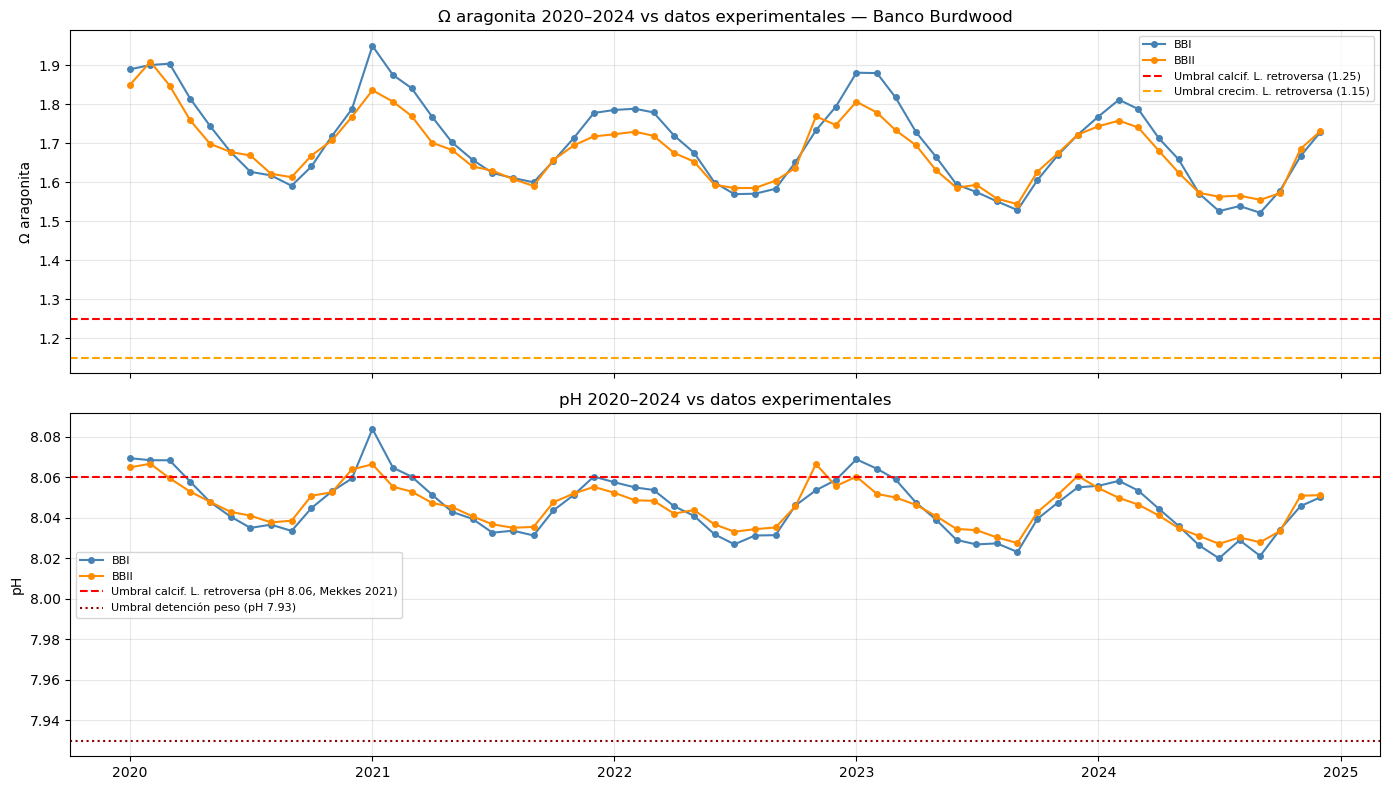

In [38]:
# ── Gráfico: serie 2020–2024 con líneas de umbrales ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for df_region, region_name, color in [
    (df_BBI,  "BBI",  "steelblue"),
    (df_BBII, "BBII", "darkorange")
]:
    df_recent = df_region[df_region["time"].dt.year >= 2020]

    # Panel 1: Ω aragonita
    axes[0].plot(df_recent["time"], df_recent["omega_ar"],
                 color=color, lw=1.5, marker="o", ms=4, label=region_name)

    # Panel 2: pH
    axes[1].plot(df_recent["time"], df_recent["ph"],
                 color=color, lw=1.5, marker="o", ms=4, label=region_name)

# Umbrales en panel Ω ara
axes[0].axhline(1.25, color="red",    lw=1.5, ls="--",
                label="Umbral calcif. L. retroversa (1.25)") #no es un umbral, es lo que observaron en el experimneto
axes[0].axhline(1.15, color="orange", lw=1.5, ls="--",
                label="Umbral crecim. L. retroversa (1.15)") #no es un umbral, es lo que observaron en el experimneto
axes[0].set_ylabel("Ω aragonita")
axes[0].set_title("Ω aragonita 2020–2024 vs datos experimentales — Banco Burdwood")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Umbrales en panel pH
axes[1].axhline(8.06, color="red",    lw=1.5, ls="--",
                label="Umbral calcif. L. retroversa (pH 8.06, Mekkes 2021)") #no es un umbral, es lo que observaron en el experimneto
axes[1].axhline(7.93, color="darkred",lw=1.5, ls=":",
                label="Umbral detención peso (pH 7.93)") #no es un umbral, es lo que observaron en el experimneto
axes[1].set_ylabel("pH")
axes[1].set_title("pH 2020–2024 vs datos experimentales")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "umbrales_2020_2024.png"), dpi=150)
plt.show()

### Figuras para el paper

#### Fig 2

In [39]:
# ## Figure 2 — Sistema de carbonatos integrado
# ## 5 paneles: pH, Ω_ar, Ω_ca, pCO2, Revelle
# ## BBI y BBII superpuestos, tendencias STL, umbrales biológicos
 
# import os
# import numpy as np
# import pandas as pd
# import xarray as xr
# import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# from statsmodels.tsa.seasonal import STL
 
# BASE_DIR      = os.path.abspath("..")
# PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
# FIGURES_DIR   = os.path.join(BASE_DIR, "figures")

In [40]:
# =============================================================================
# CELDA 1 — Cargar datos y calcular promedios espaciales
# =============================================================================
 
def spatial_mean_weighted(ds, varname):
    weights = np.cos(np.deg2rad(ds["latitude"]))
    return (ds[varname]
            .weighted(weights)
            .mean(dim=["latitude", "longitude"], skipna=True))
 
def load_region(filename, variables):
    ds = xr.open_dataset(os.path.join(PROCESSED_DIR, filename))
    ds = ds.sortby("time").drop_duplicates(dim="time")
    df = pd.DataFrame({"time": pd.to_datetime(ds.time.values)})
    for var in variables:
        df[var] = spatial_mean_weighted(ds, var).values
    df["month"] = df["time"].dt.month
    return df
 
VARS = ["ph", "omega_ar", "omega_ca", "spco2", "talk", "tco2"]
 
df_BBI  = load_region("ph_BBI_ready.nc",  VARS)
df_BBII = load_region("ph_BBII_ready.nc", VARS)
 
# Calcular Factor de Revelle
for df in [df_BBI, df_BBII]:
    denom = df["talk"] - df["tco2"]
    df["revelle"] = np.where(denom > 10, df["tco2"] / denom, np.nan)
 
print("Datos cargados ✅")
print(f"Período: {df_BBI['time'].iloc[0].date()} → {df_BBI['time'].iloc[-1].date()}")

Datos cargados ✅
Período: 1985-01-01 → 2024-12-01


In [41]:
# =============================================================================
# CELDA 2 — Función STL
# =============================================================================
 
def get_stl_trend(df, varname):
    series = df.set_index("time")[varname].asfreq("MS")
    result = STL(series, period=12, robust=True).fit()
    return result.trend.values

In [42]:
for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
    results = pyco2.sys(
        par1=df["talk"].values,
        par2=df["tco2"].values,
        par1_type=1,
        par2_type=2,
        salinity=34.5,
        temperature=5.0,
        pressure=0,
    )
    df["revelle"] = results["revelle_factor"]

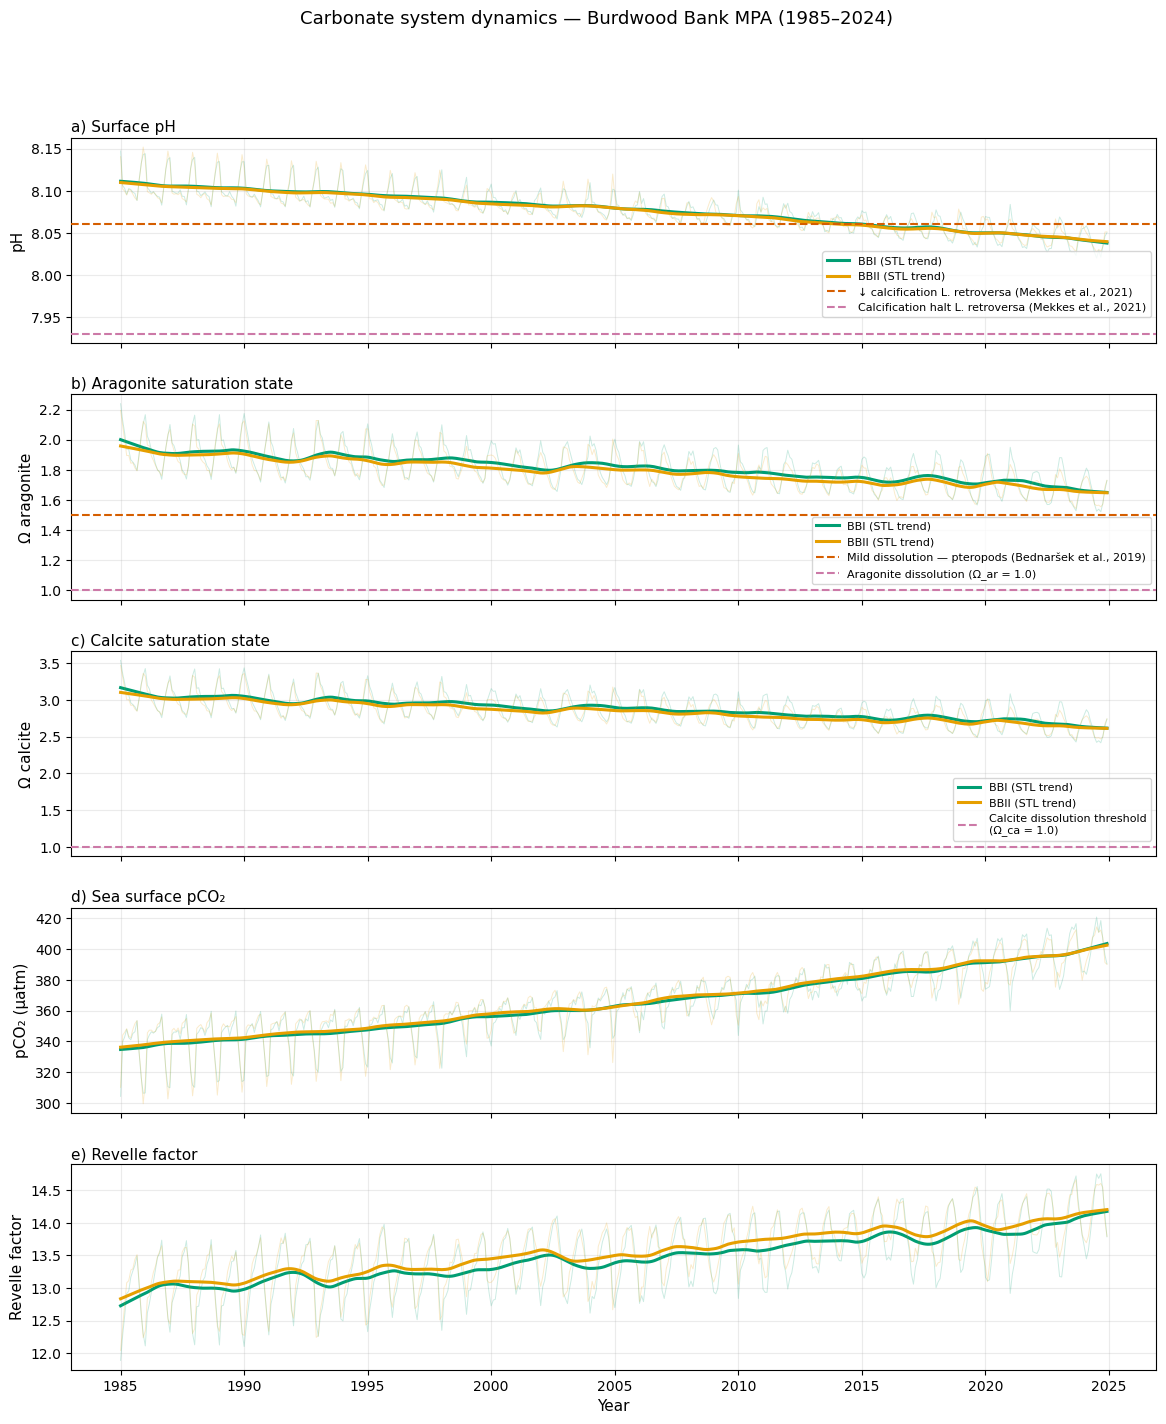

✅ Fig2_carbonate_system.png guardada


In [43]:
# =============================================================================
# CELDA 3 — Figura 2
# =============================================================================
 
PANELS = [
    {
        "var"      : "ph",
        "ylabel"   : "pH",
        "title"    : "a) Surface pH",
        "thresholds": [
            (8.06, COLOR_WARN, "--", "↓ calcification L. retroversa (Mekkes et al., 2021)"),
            (7.93, COLOR_CRIT, "--", "Calcification halt L. retroversa (Mekkes et al., 2021)"),
],
     
    },
    {
        "var"      : "omega_ar",
        "ylabel"   : "Ω aragonite",
        "title"    : "b) Aragonite saturation state",
        "thresholds": [
            (1.5, COLOR_WARN, "--", "Mild dissolution — pteropods (Bednaršek et al., 2019)"),
            (1.0, COLOR_CRIT, "--", "Aragonite dissolution (Ω_ar = 1.0)"),
],
    
    },
    {
        "var"      : "omega_ca",
        "ylabel"   : "Ω calcite",
        "title"    : "c) Calcite saturation state",
        "thresholds": [
            (1.0, COLOR_CRIT, "--",
             "Calcite dissolution threshold\n(Ω_ca = 1.0)"),
        ],
    },
    {
        "var"      : "spco2",
        "ylabel"   : "pCO₂ (µatm)",
        "title"    : "d) Sea surface pCO₂",
        "thresholds": [],  # umbral de E. huxleyi va en Fig 6 (CMIP6)
    },
    {
        "var"      : "revelle",
        "ylabel"   : "Revelle factor",
        "title"    : "e) Revelle factor",
        "thresholds": [
        ],
    },
]
 
COLORS = {"BBI": "#009E73", "BBII": "#E69F00"}
 
fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(5, 1, hspace=0.25)
 
for i, panel in enumerate(PANELS):
    ax  = fig.add_subplot(gs[i])
    var = panel["var"]
 
    for df, region in [(df_BBI, "BBI"), (df_BBII, "BBII")]:
        color = COLORS[region]
 
        # Serie mensual (fondo, transparente)
        ax.plot(df["time"], df[var],
                color=color, alpha=0.2, lw=0.7)
 
        # Tendencia STL
        trend = get_stl_trend(df, var)
        ax.plot(df["time"], trend,
                color=color, lw=2.2,
                label=f"{region} (STL trend)")
 
    # Umbrales biológicos
    for val, color, ls, label in panel["thresholds"]:
        ax.axhline(val, color=color, lw=1.5,
                   linestyle=ls, label=label, zorder=3)

 
    ax.set_ylabel(panel["ylabel"], fontsize=11)
    ax.set_title(panel["title"], fontsize=11, loc="left", pad=4)
    ax.grid(alpha=0.25)
 
    # Leyenda solo en el primer panel
    if i == 0:
        ax.legend(fontsize=8, loc="lower right",
                  bbox_to_anchor=(1, 0.1))
    elif panel["thresholds"]:
        ax.legend(fontsize=8, loc="lower right",
                  bbox_to_anchor=(1, 0.05))
 
    # Eje X solo en el último panel
    if i < len(PANELS) - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel("Year", fontsize=11)
 
plt.suptitle(
    "Carbonate system dynamics — Burdwood Bank MPA (1985–2024)",
    fontsize=13, y=0.96
)
 
plt.savefig(
    os.path.join(FIGURES_DIR, "Fig2_carbonate_system.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Fig2_carbonate_system.png guardada")
 

#### Fig 3

In [44]:
# =============================================================================
# CELDA 1 — Cargar datos
# =============================================================================
 
def spatial_mean_weighted(ds, varname):
    weights = np.cos(np.deg2rad(ds["latitude"]))
    return ds[varname].weighted(weights).mean(
        dim=["latitude", "longitude"], skipna=True)
 
def load_vars(filename, variables):
    ds = xr.open_dataset(os.path.join(PROCESSED_DIR, filename))
    ds = ds.sortby("time").drop_duplicates(dim="time")
    df = pd.DataFrame({"time": pd.to_datetime(ds.time.values)})
    for var in variables:
        df[var] = spatial_mean_weighted(ds, var).values
    df["month"] = df["time"].dt.month
    return df
 
VARS = ["ph", "omega_ar", "omega_ca", "spco2"]
 
df_BBI  = load_vars("ph_BBI_ready.nc",  VARS)
df_BBII = load_vars("ph_BBII_ready.nc", VARS)

In [45]:
# =============================================================================
# CELDA 2 — Calcular anomalías y CUSUM
# =============================================================================
 
def get_anomalies(df, varname):
    clim    = df.groupby("month")[varname].mean()
    return df[varname] - df["month"].map(clim)
 
def get_cusum(anomalies):
    """
    El punto de cambio es siempre el MÁXIMO del CUSUM.
    Para variables que bajan (pH, omega): las anomalías son positivas
    antes del cambio y negativas después → CUSUM sube y luego baja → argmax
    Para variables que suben (spco2): anomalías negativas antes, positivas
    después → CUSUM baja y luego sube → argmax del valor absoluto... 
    pero en realidad para spco2 hay que invertir la señal primero.
    """
    cusum = np.cumsum(anomalies.values)
    idx   = np.argmax(cusum)
    return cusum, idx
 
 
 

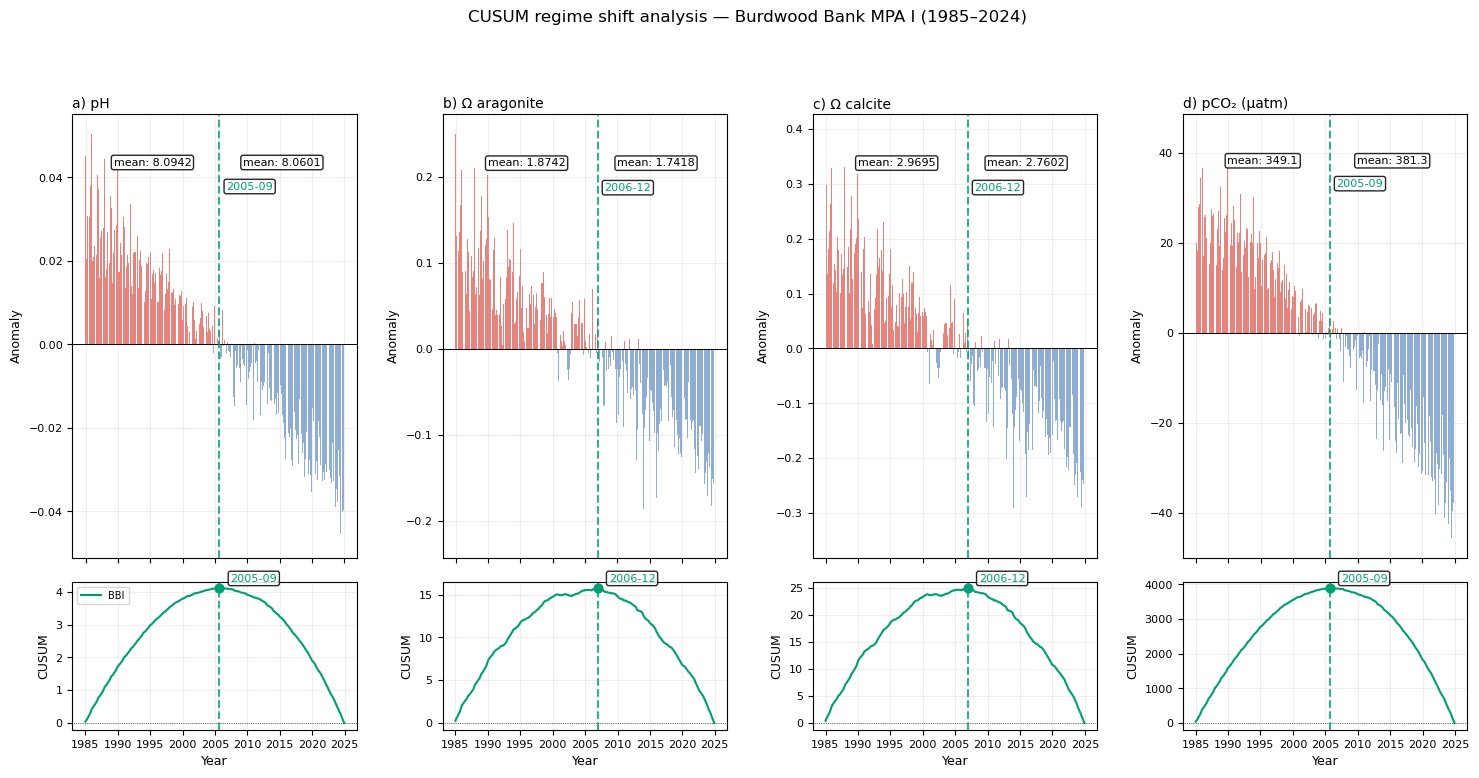

✅ Fig3_CUSUM_allvarsBBI.png guardada


In [46]:
# =============================================================================
# CELDA 3 — Figura 3 para BBI
# =============================================================================
 
PANELS = [
    {"var": "ph",       "label": "pH",            "letter": "a"},
    {"var": "omega_ar", "label": "Ω aragonite",    "letter": "b"},
    {"var": "omega_ca", "label": "Ω calcite",      "letter": "c"},
    {"var": "spco2",    "label": "pCO₂ (µatm)",   "letter": "d"},
]

COLORS = {"BBI": "#009E73", "BBII": "#E69F00"}

fig = plt.figure(figsize=(18, 8))
gs  = gridspec.GridSpec(2, 4, height_ratios=[3, 1],
                         hspace=0.08, wspace=0.3)

for col, panel in enumerate(PANELS):
    var = panel["var"]

    anom_BBI = get_anomalies(df_BBI, var)
    if var == "spco2":
        anom_BBI = -anom_BBI
    cusum_BBI, idx_BBI = get_cusum(anom_BBI)
    t_BBI = pd.Timestamp(df_BBI["time"].values[idx_BBI])

    mean_pre  = df_BBI[df_BBI["time"] <= t_BBI][var].mean()
    mean_post = df_BBI[df_BBI["time"] >  t_BBI][var].mean()

    times = pd.to_datetime(df_BBI["time"].values)

    ax_top = fig.add_subplot(gs[0, col])

    t_mid_pre  = pd.to_datetime(df_BBI["time"][df_BBI["time"] <= t_BBI].mean())
    t_mid_post = pd.to_datetime(df_BBI["time"][df_BBI["time"] >  t_BBI].mean())

    fmt = ".4f" if var in ["ph", "omega_ar", "omega_ca"] else ".1f"

    ax_top.annotate(
        f"mean: {mean_pre:{fmt}}",
        xy=(t_mid_pre, anom_BBI.max() * 0.85),
        ha="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )
    ax_top.annotate(
        f"mean: {mean_post:{fmt}}",
        xy=(t_mid_post, anom_BBI.max() * 0.85),
        ha="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )

    bar_colors = ["#d73027" if v > 0 else "#4575b4" for v in anom_BBI.values]
    ax_top.bar(times, anom_BBI.values,
               color=bar_colors, alpha=0.6, width=25)

    ax_top.axhline(0, color="black", lw=0.7)
    ax_top.axvline(t_BBI, color=COLORS["BBI"], lw=1.5,
                   linestyle="--", alpha=0.8)
    ax_top.annotate(
        t_BBI.strftime("%Y-%m"),
        xy=(t_BBI, anom_BBI.max() * 0.75),
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=8, color=COLORS["BBI"],
        va="center", ha="left",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )

    ax_top.set_title(f"{panel['letter']}) {panel['label']}",
                     fontsize=10, loc="left", pad=4)
    ax_top.set_ylabel("Anomaly", fontsize=9)
    ax_top.grid(alpha=0.2)
    ax_top.set_xticklabels([])
    ax_top.tick_params(labelsize=8)

    ax_bot = fig.add_subplot(gs[1, col])

    ax_bot.plot(times, cusum_BBI,
                color=COLORS["BBI"], lw=1.5, label="BBI")

    ax_bot.axhline(0, color="black", lw=0.5, linestyle=":")
    ax_bot.axvline(t_BBI, color=COLORS["BBI"],
                   lw=1.5, linestyle="--", alpha=0.8)

    ax_bot.scatter([t_BBI], [cusum_BBI[idx_BBI]],
                   color=COLORS["BBI"], s=40, zorder=5)
    ax_bot.annotate(
        t_BBI.strftime("%Y-%m"),
        xy=(t_BBI, cusum_BBI[idx_BBI]),
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=8, color=COLORS["BBI"],
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )

    ax_bot.set_ylabel("CUSUM", fontsize=9)
    ax_bot.set_xlabel("Year", fontsize=9)
    ax_bot.grid(alpha=0.2)
    ax_bot.tick_params(labelsize=8)

    if col == 0:
        ax_bot.legend(fontsize=7, loc="upper left")

plt.suptitle(
    "CUSUM regime shift analysis — Burdwood Bank MPA I (1985–2024)",
    fontsize=12, y=1.01
)

plt.savefig(
    os.path.join(FIGURES_DIR, "Fig3_CUSUM_allvarsBBI.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Fig3_CUSUM_allvarsBBI.png guardada")

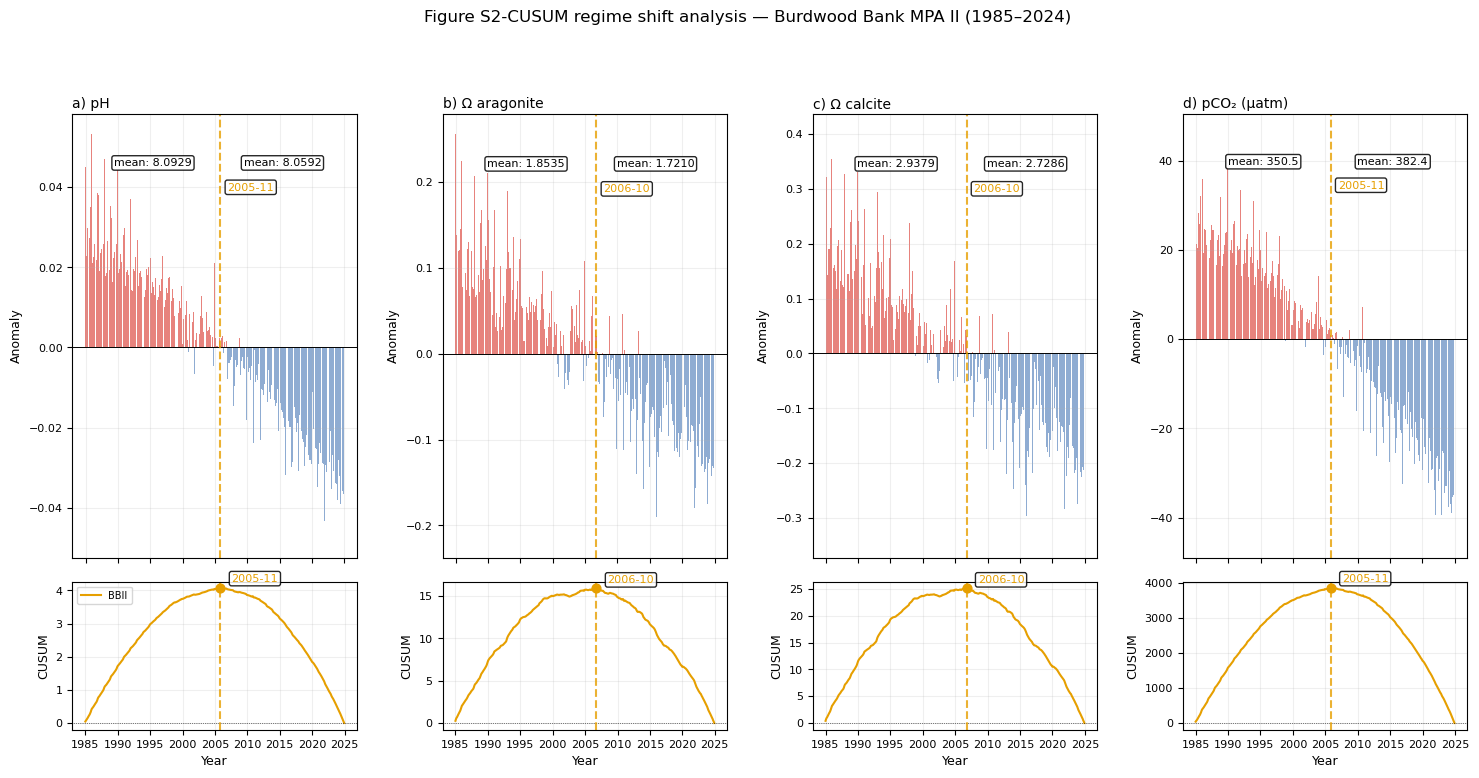

✅ Fig3_CUSUM_allvarsBBII.png guardada


In [49]:
# =============================================================================
# CELDA 3b — Figura 3 para BBII
# =============================================================================
 
PANELS = [
    {"var": "ph",       "label": "pH",            "letter": "a"},
    {"var": "omega_ar", "label": "Ω aragonite",    "letter": "b"},
    {"var": "omega_ca", "label": "Ω calcite",      "letter": "c"},
    {"var": "spco2",    "label": "pCO₂ (µatm)",   "letter": "d"},
]
 
COLORS = {"BBI": "#009E73", "BBII": "#E69F00"}
 
fig = plt.figure(figsize=(18, 8))
gs  = gridspec.GridSpec(2, 4, height_ratios=[3, 1],
                         hspace=0.08, wspace=0.3)
 
for col, panel in enumerate(PANELS):
    var = panel["var"]
 
    anom_BBII = get_anomalies(df_BBII, var)
    if var == "spco2":
        anom_BBII = -anom_BBII
    cusum_BBII, idx_BBII = get_cusum(anom_BBII)
    t_BBII = pd.Timestamp(df_BBII["time"].values[idx_BBII])
 
    mean_pre  = df_BBII[df_BBII["time"] <= t_BBII][var].mean()
    mean_post = df_BBII[df_BBII["time"] >  t_BBII][var].mean()
 
    times = pd.to_datetime(df_BBII["time"].values)
 
    ax_top = fig.add_subplot(gs[0, col])
 
    t_mid_pre  = pd.to_datetime(df_BBII["time"][df_BBII["time"] <= t_BBII].mean())
    t_mid_post = pd.to_datetime(df_BBII["time"][df_BBII["time"] >  t_BBII].mean())
 
    fmt = ".4f" if var in ["ph", "omega_ar", "omega_ca"] else ".1f"
 
    ax_top.annotate(
        f"mean: {mean_pre:{fmt}}",
        xy=(t_mid_pre, anom_BBII.max() * 0.85),
        ha="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )
    ax_top.annotate(
        f"mean: {mean_post:{fmt}}",
        xy=(t_mid_post, anom_BBII.max() * 0.85),
        ha="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )
 
    bar_colors = ["#d73027" if v > 0 else "#4575b4" for v in anom_BBII.values]
    ax_top.bar(times, anom_BBII.values,
               color=bar_colors, alpha=0.6, width=25)
 
    ax_top.axhline(0, color="black", lw=0.7)
    ax_top.axvline(t_BBII, color=COLORS["BBII"], lw=1.5,
                   linestyle="--", alpha=0.8)
    ax_top.annotate(
        t_BBII.strftime("%Y-%m"),
        xy=(t_BBII, anom_BBII.max() * 0.75),
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=8, color=COLORS["BBII"],
        va="center", ha="left",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )
 
    ax_top.set_title(f"{panel['letter']}) {panel['label']}",
                     fontsize=10, loc="left", pad=4)
    ax_top.set_ylabel("Anomaly", fontsize=9)
    ax_top.grid(alpha=0.2)
    ax_top.set_xticklabels([])
    ax_top.tick_params(labelsize=8)
 
    ax_bot = fig.add_subplot(gs[1, col])
 
    ax_bot.plot(times, cusum_BBII,
                color=COLORS["BBII"], lw=1.5, label="BBII")
 
    ax_bot.axhline(0, color="black", lw=0.5, linestyle=":")
    ax_bot.axvline(t_BBII, color=COLORS["BBII"],
                   lw=1.5, linestyle="--", alpha=0.8)
 
    ax_bot.scatter([t_BBII], [cusum_BBII[idx_BBII]],
                   color=COLORS["BBII"], s=40, zorder=5)
    ax_bot.annotate(
        t_BBII.strftime("%Y-%m"),
        xy=(t_BBII, cusum_BBII[idx_BBI]),
        xytext=(8, 5),
        textcoords="offset points",
        fontsize=8, color=COLORS["BBII"],
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )
 
    ax_bot.set_ylabel("CUSUM", fontsize=9)
    ax_bot.set_xlabel("Year", fontsize=9)
    ax_bot.grid(alpha=0.2)
    ax_bot.tick_params(labelsize=8)
 
    if col == 0:
        ax_bot.legend(fontsize=7, loc="upper left")
 
plt.suptitle(
    "Figure S2-CUSUM regime shift analysis — Burdwood Bank MPA II (1985–2024)",
    fontsize=12, y=1.01
)
 
plt.savefig(
    os.path.join(FIGURES_DIR, "Fig3_CUSUM_allvarsBBII.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Fig3_CUSUM_allvarsBBII.png guardada")
 